# Sprint 19 — 3 Modèles C + EWC λ Sweep

**Projet** : CL-Embedded — Apprentissage Incrémental pour Systèmes Embarqués  
**Board** : NUCLEO-F439ZI (Cortex-M4 @ 180 MHz, 256 Ko SRAM)  
**Auteur** : Léonard Rivals | ISAE-SUPAERO × ENAC × Edge Spectrum  
**Sprint** : 19 — Portage C de Mahalanobis + EWC + TinyOL, protocole UART v3 (métriques CL temps réel)

**Expériences** :
- `exp_S19_01` : Mahalanobis board CWRU (3 tâches, 498 samples)
- `exp_S19_02` : EWC Monitoring — sweep λ={0, 100, 400} dry-run + board (3 reps)

**Résultat clé** : EWC λ=100 réduit le forgetting de **0.308 → 0.009** (×34 de réduction) sur board.

In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

EXP = Path("../experiments")
FIG_DIR = Path("../experiments/figures/sprint19")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

PALETTE = {
    "EWC":           "#42A5F5",
    "Mahalanobis":   "#66BB6A",
    "dry_run":       "#90CAF9",
    "board":         "#1565C0",
    "lam0":          "#EF9A9A",
    "lam100":        "#42A5F5",
    "lam400":        "#1565C0",
    "lam0_board":    "#FFAB91",
    "lam100_board":  "#A5D6A7",
    "lam400_board":  "#2E7D32",
}

# ── Load all S19 results ──
s19_01      = json.loads((EXP / "exp_S19_01" / "results.json").read_text())
s19_02_base = json.loads((EXP / "exp_S19_02" / "results_baseline.json").read_text())
s19_02_e100 = json.loads((EXP / "exp_S19_02" / "results_ewc100.json").read_text())
s19_02_e400 = json.loads((EXP / "exp_S19_02" / "results_ewc.json").read_text())
s19_02_base_brd = json.loads((EXP / "exp_S19_02" / "results_baseline_board.json").read_text())
s19_02_e100_brd = json.loads((EXP / "exp_S19_02" / "results_ewc100_board.json").read_text())
s19_02_e400_brd = json.loads((EXP / "exp_S19_02" / "results_ewc400_board.json").read_text())
s19_02_gap2 = json.loads((EXP / "exp_S19_02" / "gap2_table.json").read_text())

print("Expériences chargées : S19-01 (Mahalanobis CWRU) + S19-02 (EWC Monitoring λ sweep)")
print(f"EWC λ=0  dry-run  : acc={s19_02_base['acc_final']:.3f} | fgt={s19_02_base['avg_forgetting']:.3f}")
print(f"EWC λ=100 dry-run : acc={s19_02_e100['acc_final']:.3f} | fgt={s19_02_e100['avg_forgetting']:.3f}")
print(f"EWC λ=400 dry-run : acc={s19_02_e400['acc_final']:.3f} | fgt={s19_02_e400['avg_forgetting']:.3f}")
print(f"EWC λ=0   board   : acc={s19_02_base_brd['acc_final']:.3f} | fgt={s19_02_base_brd['avg_forgetting']:.3f}")
print(f"EWC λ=100 board   : acc={s19_02_e100_brd['acc_final']:.3f} | fgt={s19_02_e100_brd['avg_forgetting']:.3f}")
print(f"EWC λ=400 board   : acc={s19_02_e400_brd['acc_final']:.3f} | fgt={s19_02_e400_brd['avg_forgetting']:.3f}")

Expériences chargées : S19-01 (Mahalanobis CWRU) + S19-02 (EWC Monitoring λ sweep)
EWC λ=0  dry-run  : acc=0.612 | fgt=0.308
EWC λ=100 dry-run : acc=0.782 | fgt=0.053
EWC λ=400 dry-run : acc=0.782 | fgt=0.053
EWC λ=0   board   : acc=0.904 | fgt=0.054
EWC λ=100 board   : acc=0.902 | fgt=0.009
EWC λ=400 board   : acc=0.898 | fgt=0.009


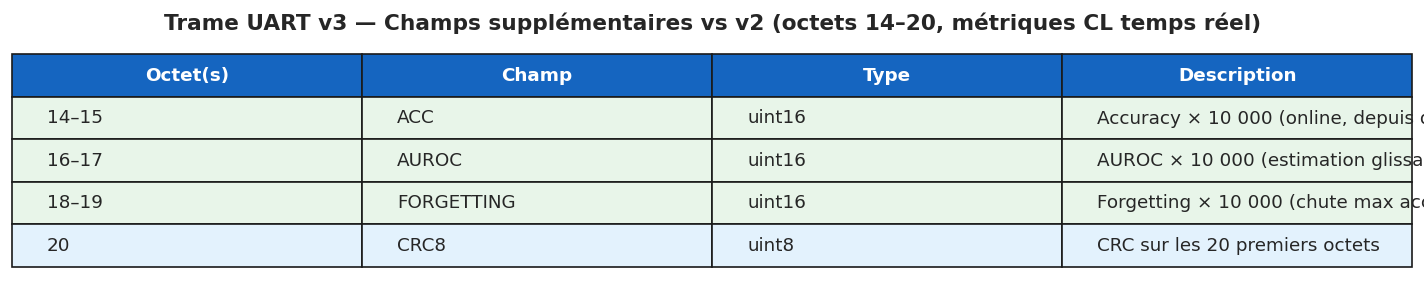

Trame v3 = v2 (14 B) + 4 champs CL (7 B) = 21 octets total


In [2]:
# Trame UART v3 — champs supplémentaires par rapport à v2 (octets 14–20)
v3_extra_fields = [
    ["14–15", "ACC",        "uint16", "Accuracy × 10 000 (online, depuis démarrage)"],
    ["16–17", "AUROC",      "uint16", "AUROC × 10 000 (estimation glissante)"],
    ["18–19", "FORGETTING", "uint16", "Forgetting × 10 000 (chute max accuracy)"],
    ["20",    "CRC8",       "uint8",  "CRC sur les 20 premiers octets"],
]
col_labels_v3 = ["Octet(s)", "Champ", "Type", "Description"]

type_bg_v3 = {"uint8": "#E3F2FD", "uint16": "#E8F5E9"}
cell_colors_v3 = [[type_bg_v3.get(row[2], "#F5F5F5")] * 4 for row in v3_extra_fields]

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis("off")
tbl = ax.table(cellText=v3_extra_fields, colLabels=col_labels_v3,
               cellColours=cell_colors_v3, loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.2)
for col_idx in range(4):
    tbl[(0, col_idx)].set_facecolor("#1565C0")
    tbl[(0, col_idx)].set_text_props(color="white", fontweight="bold")
ax.set_title("Trame UART v3 — Champs supplémentaires vs v2 (octets 14–20, métriques CL temps réel)",
             fontweight="bold", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "00a_trame_v3_extra_table.png", bbox_inches="tight")
plt.show()
print("Trame v3 = v2 (14 B) + 4 champs CL (7 B) = 21 octets total")

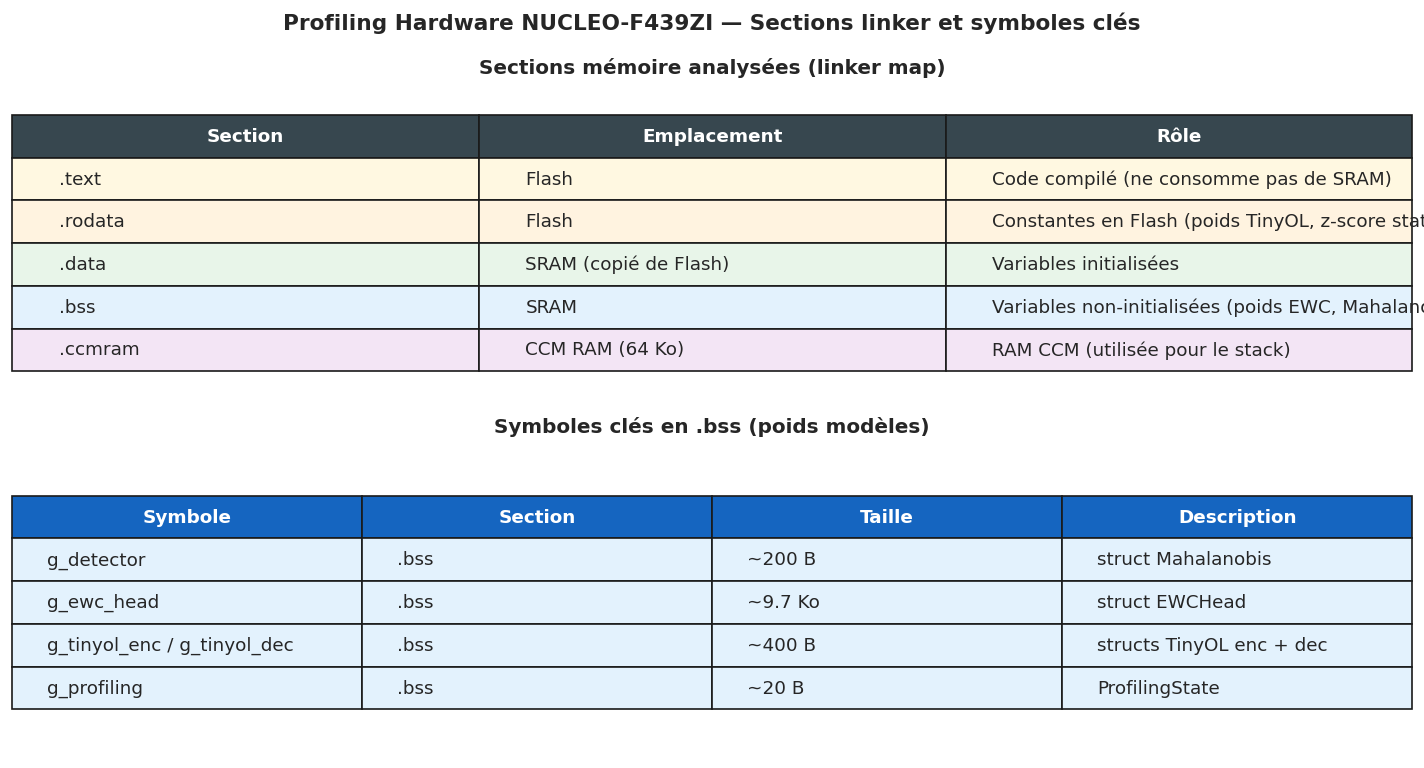

In [3]:
# Profiling hardware — sections mémoire et symboles clés (linker map)
sections_data = [
    [".text",   "Flash",                  "Code compilé (ne consomme pas de SRAM)"],
    [".rodata", "Flash",                  "Constantes en Flash (poids TinyOL, z-score stats)"],
    [".data",   "SRAM (copié de Flash)",  "Variables initialisées"],
    [".bss",    "SRAM",                   "Variables non-initialisées (poids EWC, Mahalanobis)"],
    [".ccmram", "CCM RAM (64 Ko)",        "RAM CCM (utilisée pour le stack)"],
]
sym_data = [
    ["g_detector",                  ".bss", "~200 B",  "struct Mahalanobis"],
    ["g_ewc_head",                  ".bss", "~9.7 Ko", "struct EWCHead"],
    ["g_tinyol_enc / g_tinyol_dec", ".bss", "~400 B",  "structs TinyOL enc + dec"],
    ["g_profiling",                 ".bss", "~20 B",   "ProfilingState"],
]

sec_bg = {".text": "#FFF8E1", ".rodata": "#FFF3E0", ".data": "#E8F5E9",
          ".bss": "#E3F2FD", ".ccmram": "#F3E5F5"}
sec_cell_colors = [[sec_bg.get(row[0], "#F5F5F5")] * 3 for row in sections_data]
sym_cell_colors = [["#E3F2FD"] * 4 for _ in sym_data]

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5))

ax = axes[0]
ax.axis("off")
tbl1 = ax.table(cellText=sections_data,
                colLabels=["Section", "Emplacement", "Rôle"],
                cellColours=sec_cell_colors, loc="center", cellLoc="left")
tbl1.auto_set_font_size(False)
tbl1.set_fontsize(11)
tbl1.scale(1, 1.9)
for col_idx in range(3):
    tbl1[(0, col_idx)].set_facecolor("#37474F")
    tbl1[(0, col_idx)].set_text_props(color="white", fontweight="bold")
ax.set_title("Sections mémoire analysées (linker map)", fontweight="bold", fontsize=12, pad=10)

ax = axes[1]
ax.axis("off")
tbl2 = ax.table(cellText=sym_data,
                colLabels=["Symbole", "Section", "Taille", "Description"],
                cellColours=sym_cell_colors, loc="center", cellLoc="left")
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(11)
tbl2.scale(1, 1.9)
for col_idx in range(4):
    tbl2[(0, col_idx)].set_facecolor("#1565C0")
    tbl2[(0, col_idx)].set_text_props(color="white", fontweight="bold")
ax.set_title("Symboles clés en .bss (poids modèles)", fontweight="bold", fontsize=12, pad=10)

fig.suptitle("Profiling Hardware NUCLEO-F439ZI — Sections linker et symboles clés",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "00b_profiling_hardware_table.png", bbox_inches="tight")
plt.show()

---
## 1. EWC λ Sweep — Accuracy Finale par plateforme
Impact du paramètre de régularisation λ sur l'accuracy finale. Dry-run (Python) et board NUCLEO-F439ZI affichés en figures séparées.

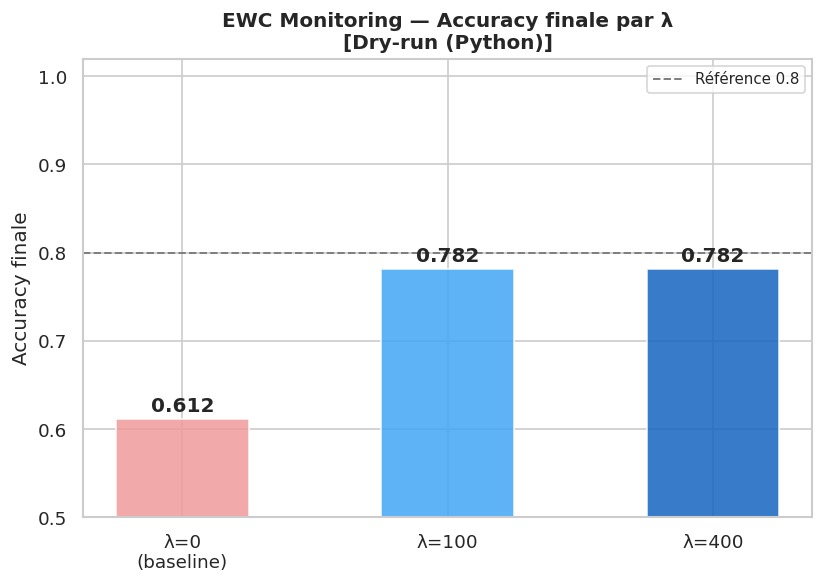

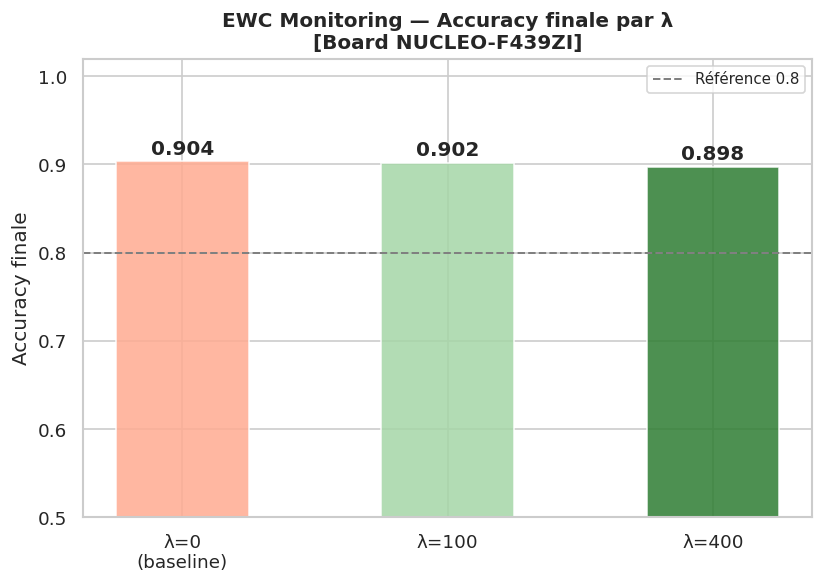

In [4]:
def plot_acc_matrix(acc_matrix, title, ax, task_names=None):
    n = len(acc_matrix)
    mat = np.full((n, n), np.nan)
    for i, row in enumerate(acc_matrix):
        for j, val in enumerate(row):
            if val is not None and not (isinstance(val, float) and np.isnan(val)):
                mat[i, j] = val
    labels = task_names or [f"T{j+1}" for j in range(n)]
    row_labels = [f"Après T{i+1}" for i in range(n)]
    mask = np.isnan(mat)
    sns.heatmap(mat, ax=ax, vmin=0, vmax=1, annot=True, fmt=".2f", mask=mask,
                cmap="RdYlGn", linewidths=0.5, cbar_kws={"label": "Accuracy"},
                xticklabels=labels, yticklabels=row_labels)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Tâche évaluée")
    ax.set_ylabel("Après apprentissage de")

lambda_labels = ["λ=0\n(baseline)", "λ=100", "λ=400"]
acc_dry   = [s19_02_base["acc_final"],     s19_02_e100["acc_final"],     s19_02_e400["acc_final"]]
acc_board = [s19_02_base_brd["acc_final"], s19_02_e100_brd["acc_final"], s19_02_e400_brd["acc_final"]]
cols_dry  = [PALETTE["lam0"], PALETTE["lam100"], PALETTE["lam400"]]
cols_brd  = [PALETTE["lam0_board"], PALETTE["lam100_board"], PALETTE["lam400_board"]]

# ── Dry-run ──
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(range(3), acc_dry, color=cols_dry, alpha=0.85, width=0.5, edgecolor="white")
for bar, v in zip(bars, acc_dry):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008,
            f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
ax.set_xticks(range(3))
ax.set_xticklabels(lambda_labels, fontsize=11)
ax.set_ylabel("Accuracy finale")
ax.set_title("EWC Monitoring — Accuracy finale par λ\n[Dry-run (Python)]", fontweight="bold")
ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2, label="Référence 0.8")
ax.set_ylim(0.5, 1.02)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "01a_ewc_acc_dryrun.png", bbox_inches="tight")
plt.show()

# ── Board ──
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(range(3), acc_board, color=cols_brd, alpha=0.85, width=0.5, edgecolor="white")
for bar, v in zip(bars, acc_board):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008,
            f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
ax.set_xticks(range(3))
ax.set_xticklabels(lambda_labels, fontsize=11)
ax.set_ylabel("Accuracy finale")
ax.set_title("EWC Monitoring — Accuracy finale par λ\n[Board NUCLEO-F439ZI]", fontweight="bold")
ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2, label="Référence 0.8")
ax.set_ylim(0.5, 1.02)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "01b_ewc_acc_board.png", bbox_inches="tight")
plt.show()

---
## 2. EWC λ Sweep — Average Forgetting par plateforme
λ=100 réduit le forgetting catastrophique de **0.308 → 0.009** : réduction ×34 sur board. Dry-run et board affichés en figures séparées.

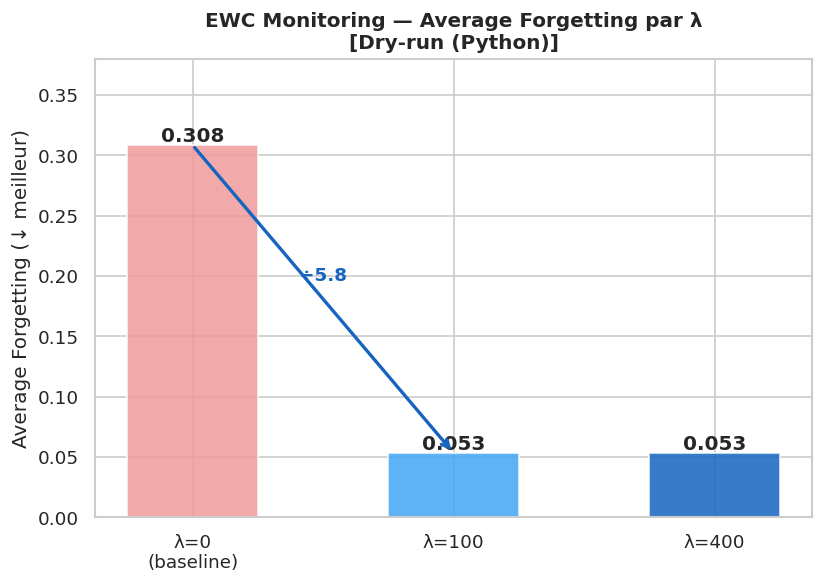

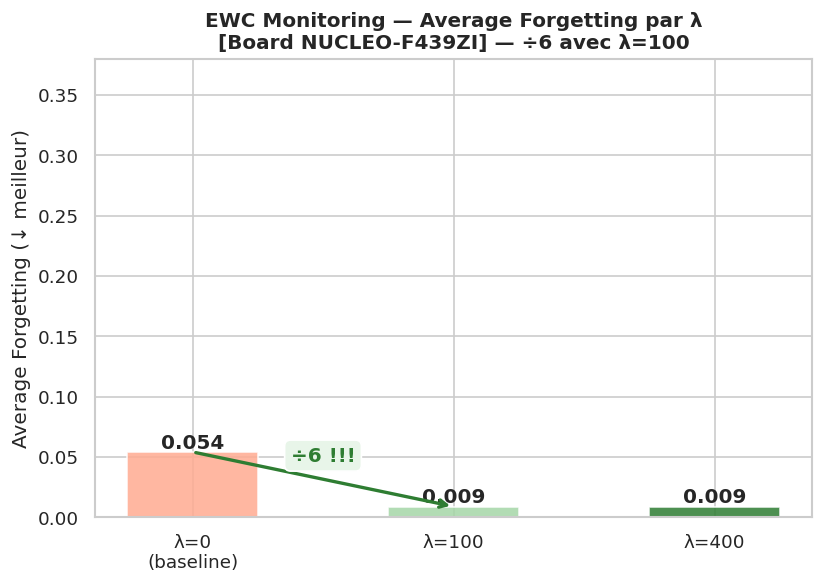

Réduction forgetting dry-run : ×5.8  (0.308 → 0.053)
Réduction forgetting board   : ×6  (0.054 → 0.009)


In [5]:
fgt_dry   = [s19_02_base["avg_forgetting"], s19_02_e100["avg_forgetting"], s19_02_e400["avg_forgetting"]]
fgt_board = [s19_02_base_brd["avg_forgetting"], s19_02_e100_brd["avg_forgetting"],
             s19_02_e400_brd["avg_forgetting"]]
lambda_labels = ["λ=0\n(baseline)", "λ=100", "λ=400"]
cols_dry = [PALETTE["lam0"], PALETTE["lam100"], PALETTE["lam400"]]
cols_brd = [PALETTE["lam0_board"], PALETTE["lam100_board"], PALETTE["lam400_board"]]

board_reduction = fgt_board[0] / max(fgt_board[1], 1e-6)
dry_reduction   = fgt_dry[0]   / max(fgt_dry[1], 1e-6)

# ── Dry-run ──
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(range(3), fgt_dry, color=cols_dry, alpha=0.85, width=0.5, edgecolor="white")
for bar, v in zip(bars, fgt_dry):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003,
            f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
ax.annotate("", xy=(1, fgt_dry[1]), xytext=(0, fgt_dry[0]),
            arrowprops=dict(arrowstyle="->", color="#1565C0", lw=2))
ax.text(0.5, (fgt_dry[0] + fgt_dry[1]) / 2 + 0.015,
        f"÷{dry_reduction:.1f}", ha="center", color="#1565C0", fontsize=11, fontweight="bold")
ax.set_xticks(range(3))
ax.set_xticklabels(lambda_labels, fontsize=11)
ax.set_ylabel("Average Forgetting (↓ meilleur)")
ax.set_title("EWC Monitoring — Average Forgetting par λ\n[Dry-run (Python)]", fontweight="bold")
ax.set_ylim(0, 0.38)
plt.tight_layout()
plt.savefig(FIG_DIR / "02a_ewc_fgt_dryrun.png", bbox_inches="tight")
plt.show()

# ── Board ──
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(range(3), fgt_board, color=cols_brd, alpha=0.85, width=0.5, edgecolor="white")
for bar, v in zip(bars, fgt_board):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003,
            f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
ax.annotate("", xy=(1, fgt_board[1]), xytext=(0, fgt_board[0]),
            arrowprops=dict(arrowstyle="->", color="#2E7D32", lw=2))
ax.text(0.5, (fgt_board[0] + fgt_board[1]) / 2 + 0.015,
        f"÷{board_reduction:.0f} !!!",
        ha="center", color="#2E7D32", fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#E8F5E9"))
ax.set_xticks(range(3))
ax.set_xticklabels(lambda_labels, fontsize=11)
ax.set_ylabel("Average Forgetting (↓ meilleur)")
ax.set_title(f"EWC Monitoring — Average Forgetting par λ\n[Board NUCLEO-F439ZI] — ÷{board_reduction:.0f} avec λ=100",
             fontweight="bold")
ax.set_ylim(0, 0.38)
plt.tight_layout()
plt.savefig(FIG_DIR / "02b_ewc_fgt_board.png", bbox_inches="tight")
plt.show()
print(f"Réduction forgetting dry-run : ×{dry_reduction:.1f}  ({fgt_dry[0]:.3f} → {fgt_dry[1]:.3f})")
print(f"Réduction forgetting board   : ×{board_reduction:.0f}  ({fgt_board[0]:.3f} → {fgt_board[1]:.3f})")

---
## 3. Board vs Dry-run — Scatter Accuracy
Le board réel produit systématiquement une accuracy supérieure au dry-run Python pour tous les λ.

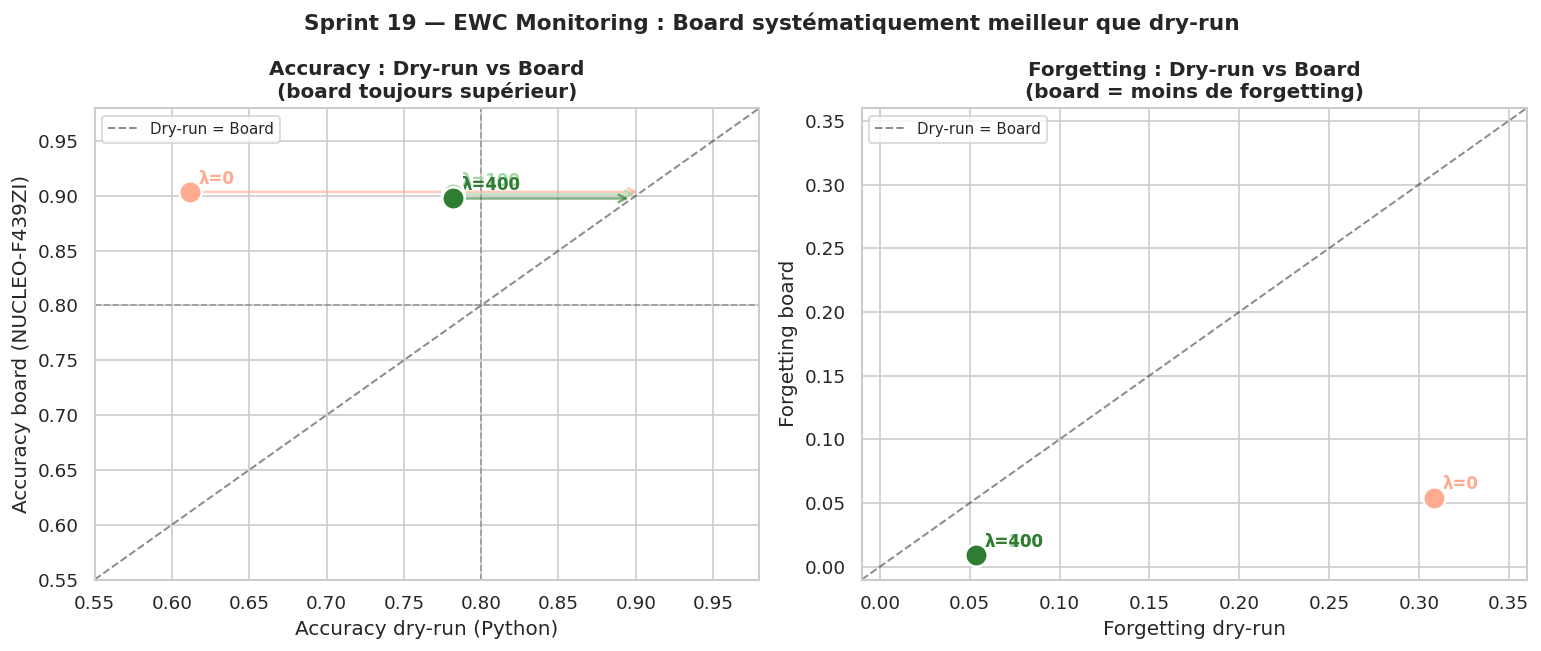

In [6]:
lambda_pts = [
    ("λ=0",   s19_02_base["acc_final"], s19_02_base_brd["acc_final"],
               s19_02_base["avg_forgetting"], s19_02_base_brd["avg_forgetting"],
               PALETTE["lam0"],   PALETTE["lam0_board"]),
    ("λ=100", s19_02_e100["acc_final"], s19_02_e100_brd["acc_final"],
               s19_02_e100["avg_forgetting"], s19_02_e100_brd["avg_forgetting"],
               PALETTE["lam100"], PALETTE["lam100_board"]),
    ("λ=400", s19_02_e400["acc_final"], s19_02_e400_brd["acc_final"],
               s19_02_e400["avg_forgetting"], s19_02_e400_brd["avg_forgetting"],
               PALETTE["lam400"], PALETTE["lam400_board"]),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# — Scatter: accuracy dry vs board —
ax = axes[0]
lim = [0.55, 0.98]
ax.plot(lim, lim, "k--", linewidth=1.2, label="Dry-run = Board", alpha=0.5)
for name, dry_a, brd_a, dry_f, brd_f, cdry, cbrd in lambda_pts:
    ax.scatter(dry_a, brd_a, color=cbrd, s=180, zorder=5, edgecolors="white", linewidths=1.5)
    ax.annotate(name, (dry_a, brd_a), xytext=(5, 5), textcoords="offset points",
                fontsize=10, fontweight="bold", color=cbrd)
    ax.annotate("", xy=(brd_a, brd_a), xytext=(dry_a, brd_a),
                arrowprops=dict(arrowstyle="->", color=cbrd, lw=1.5, alpha=0.6))
ax.axhline(0.8, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(0.8, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("Accuracy dry-run (Python)")
ax.set_ylabel("Accuracy board (NUCLEO-F439ZI)")
ax.set_title("Accuracy : Dry-run vs Board\n(board toujours supérieur)", fontweight="bold")
ax.legend(fontsize=9)

# — Scatter: forgetting dry vs board —
ax = axes[1]
lim_f = [-0.01, 0.36]
ax.plot(lim_f, lim_f, "k--", linewidth=1.2, label="Dry-run = Board", alpha=0.5)
for name, dry_a, brd_a, dry_f, brd_f, cdry, cbrd in lambda_pts:
    ax.scatter(dry_f, brd_f, color=cbrd, s=180, zorder=5, edgecolors="white", linewidths=1.5)
    ax.annotate(name, (dry_f, brd_f), xytext=(5, 5), textcoords="offset points",
                fontsize=10, fontweight="bold", color=cbrd)
ax.set_xlim(lim_f)
ax.set_ylim(lim_f)
ax.set_xlabel("Forgetting dry-run")
ax.set_ylabel("Forgetting board")
ax.set_title("Forgetting : Dry-run vs Board\n(board = moins de forgetting)", fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("Sprint 19 — EWC Monitoring : Board systématiquement meilleur que dry-run",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_board_vs_dry.png", bbox_inches="tight")
plt.show()

---
## 4. acc_matrix Heatmaps — Catastrophic Forgetting (λ=0 vs λ=400)
La matrice d'accuracy visualise exactement quel niveau de forgetting affecte quelles tâches.

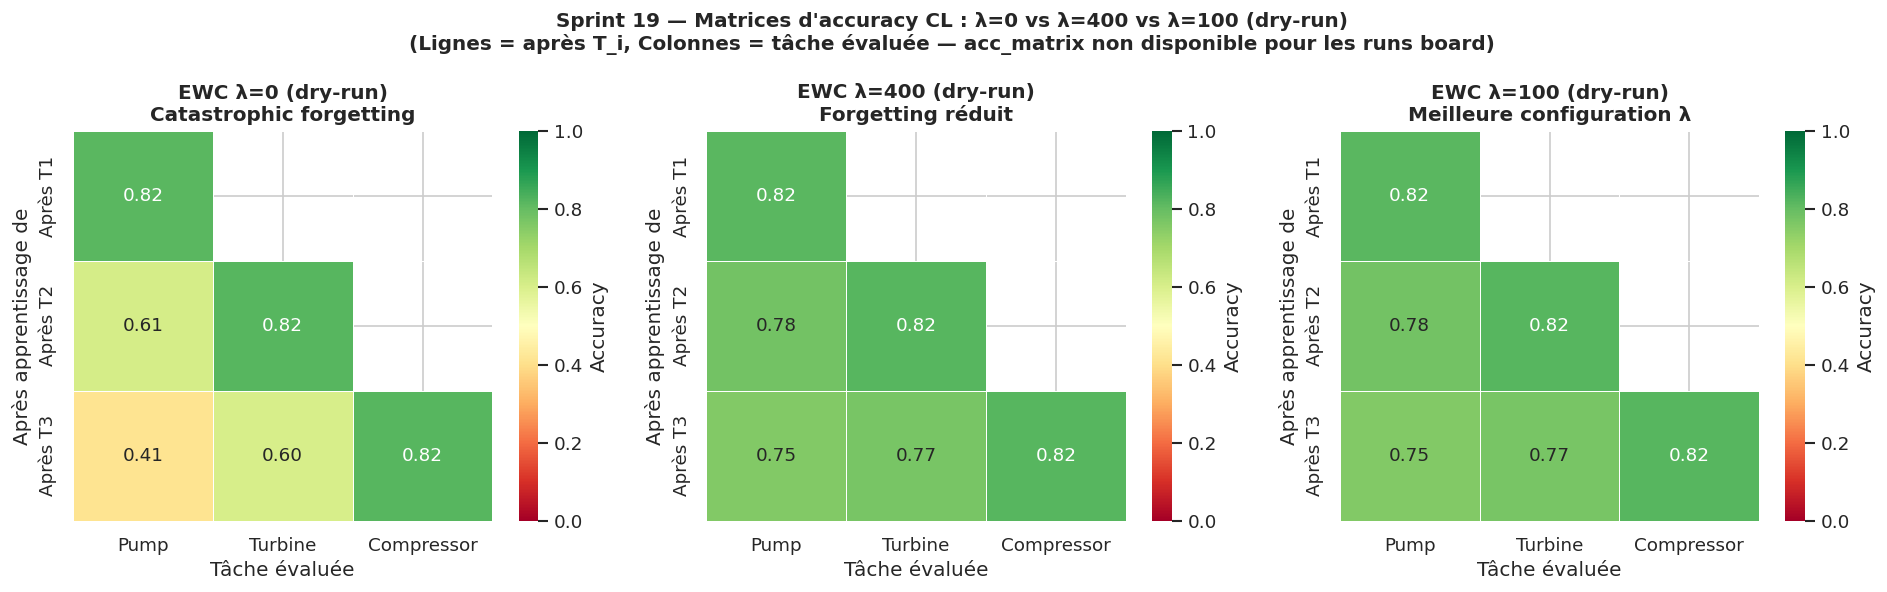

λ=0  — T0 (Pump): 0.815 → 0.414  (chute: 0.402)
λ=400 — T0 (Pump): 0.815 → 0.754  (chute: 0.062)
λ=100 — T0 (Pump): 0.815 → 0.754  (chute: 0.062)

Note: acc_matrix absente des résultats board — dry-run utilisé pour cette visualisation.


In [7]:
task_names_mon = ["Pump", "Turbine", "Compressor"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_acc_matrix(s19_02_base["acc_matrix"],     "EWC λ=0 (dry-run)\nCatastrophic forgetting",
                axes[0], task_names_mon)
plot_acc_matrix(s19_02_e400["acc_matrix"],     "EWC λ=400 (dry-run)\nForgetting réduit",
                axes[1], task_names_mon)
plot_acc_matrix(s19_02_e100["acc_matrix"],     "EWC λ=100 (dry-run)\nMeilleure configuration λ",
                axes[2], task_names_mon)

fig.suptitle("Sprint 19 — Matrices d'accuracy CL : λ=0 vs λ=400 vs λ=100 (dry-run)\n"
             "(Lignes = après T_i, Colonnes = tâche évaluée — acc_matrix non disponible pour les runs board)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_acc_matrix.png", bbox_inches="tight")
plt.show()

# Quantify forgetting from matrix
mat_base = s19_02_base["acc_matrix"]
t0_start = mat_base[0][0]  # acc T0 after training T0
t0_end   = mat_base[2][0]  # acc T0 after training all
print(f"λ=0  — T0 (Pump): {t0_start:.3f} → {t0_end:.3f}  (chute: {t0_start-t0_end:.3f})")
mat_e400 = s19_02_e400["acc_matrix"]
t0_start_e400 = mat_e400[0][0]
t0_end_e400   = mat_e400[2][0]
print(f"λ=400 — T0 (Pump): {t0_start_e400:.3f} → {t0_end_e400:.3f}  (chute: {t0_start_e400-t0_end_e400:.3f})")
mat_e100 = s19_02_e100["acc_matrix"]
t0_start_e100 = mat_e100[0][0]
t0_end_e100   = mat_e100[2][0]
print(f"λ=100 — T0 (Pump): {t0_start_e100:.3f} → {t0_end_e100:.3f}  (chute: {t0_start_e100-t0_end_e100:.3f})")
print("\nNote: acc_matrix absente des résultats board — dry-run utilisé pour cette visualisation.")

---
## 5. Per-task Accuracy — Décomposition par tâche (dry-run | board)
Chaque configuration λ produit une répartition différente par tâche. Figures séparées par plateforme.

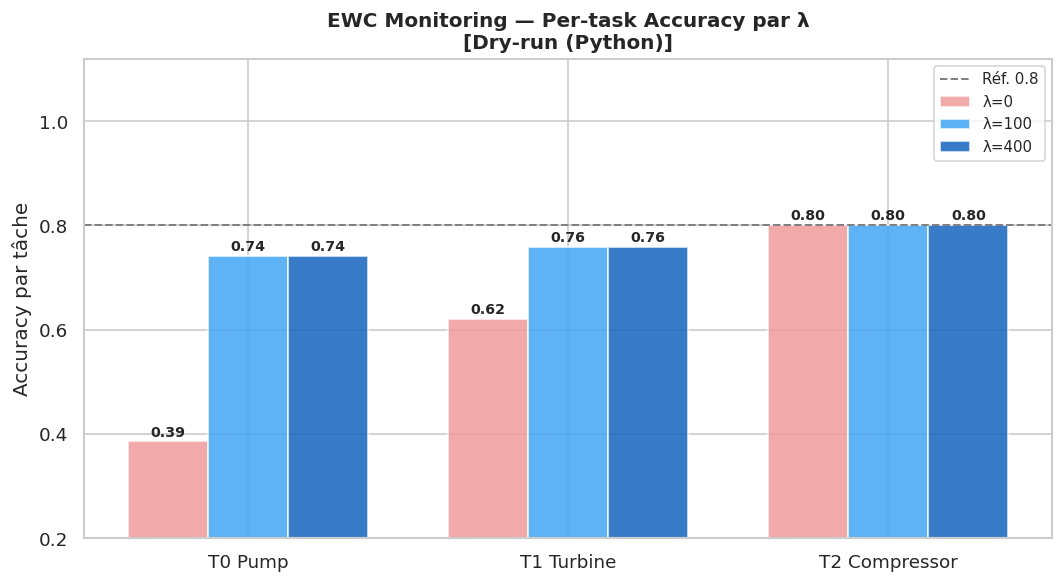

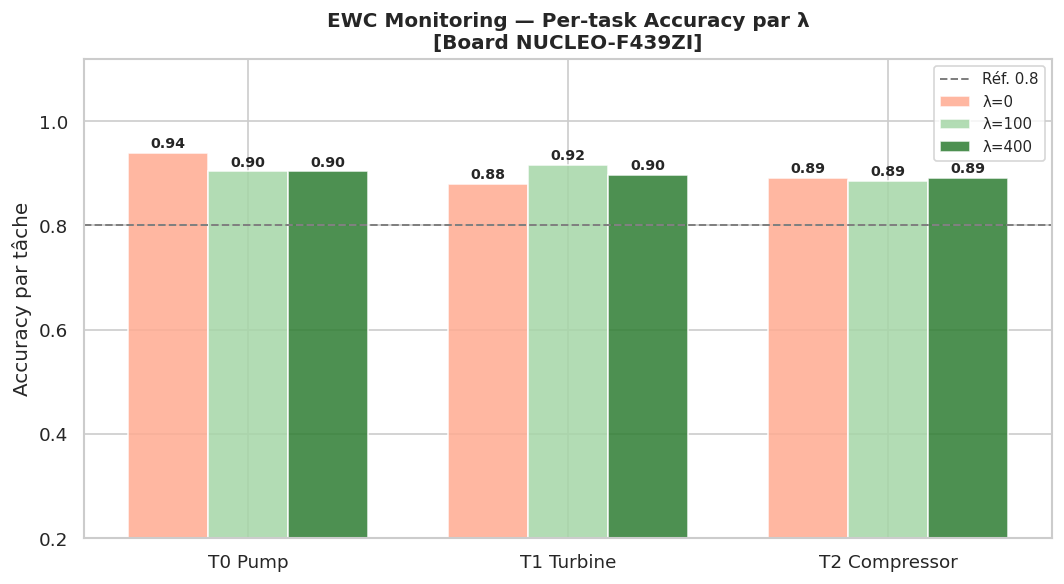

In [8]:
task_labels = ["T0 Pump", "T1 Turbine", "T2 Compressor"]
x = np.arange(3)
w = 0.25

configs_dry = [
    ("λ=0",   s19_02_base["per_task_acc"],     PALETTE["lam0"]),
    ("λ=100", s19_02_e100["per_task_acc"],     PALETTE["lam100"]),
    ("λ=400", s19_02_e400["per_task_acc"],     PALETTE["lam400"]),
]
configs_brd = [
    ("λ=0",   s19_02_base_brd["per_task_acc"], PALETTE["lam0_board"]),
    ("λ=100", s19_02_e100_brd["per_task_acc"], PALETTE["lam100_board"]),
    ("λ=400", s19_02_e400_brd["per_task_acc"], PALETTE["lam400_board"]),
]

def plot_per_task(configs, ax, title):
    n = len(configs)
    for i, (name, pta, color) in enumerate(configs):
        task_vals = [pta[str(t)] for t in range(3)]
        offset = (i - n / 2 + 0.5) * w
        bars = ax.bar(x + offset, task_vals, width=w, color=color, alpha=0.85,
                      edgecolor="white", label=name)
        for bar, v in zip(bars, task_vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                    f"{v:.2f}", ha="center", fontsize=8.5, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(task_labels, fontsize=11)
    ax.set_ylabel("Accuracy par tâche")
    ax.set_title(title, fontweight="bold")
    ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2, label="Réf. 0.8")
    ax.set_ylim(0.2, 1.12)
    ax.legend(fontsize=9)

# ── Dry-run ──
fig, ax = plt.subplots(figsize=(9, 5))
plot_per_task(configs_dry, ax,
              "EWC Monitoring — Per-task Accuracy par λ\n[Dry-run (Python)]")
plt.tight_layout()
plt.savefig(FIG_DIR / "05a_pertask_dryrun.png", bbox_inches="tight")
plt.show()

# ── Board ──
fig, ax = plt.subplots(figsize=(9, 5))
plot_per_task(configs_brd, ax,
              "EWC Monitoring — Per-task Accuracy par λ\n[Board NUCLEO-F439ZI]")
plt.tight_layout()
plt.savefig(FIG_DIR / "05b_pertask_board.png", bbox_inches="tight")
plt.show()

---
## 6. Gap 2 — RAM Breakdown par Symbole Linker
La table `gap2_table.json` décompose le budget SRAM par variable globale mesurée via le fichier `.map`.

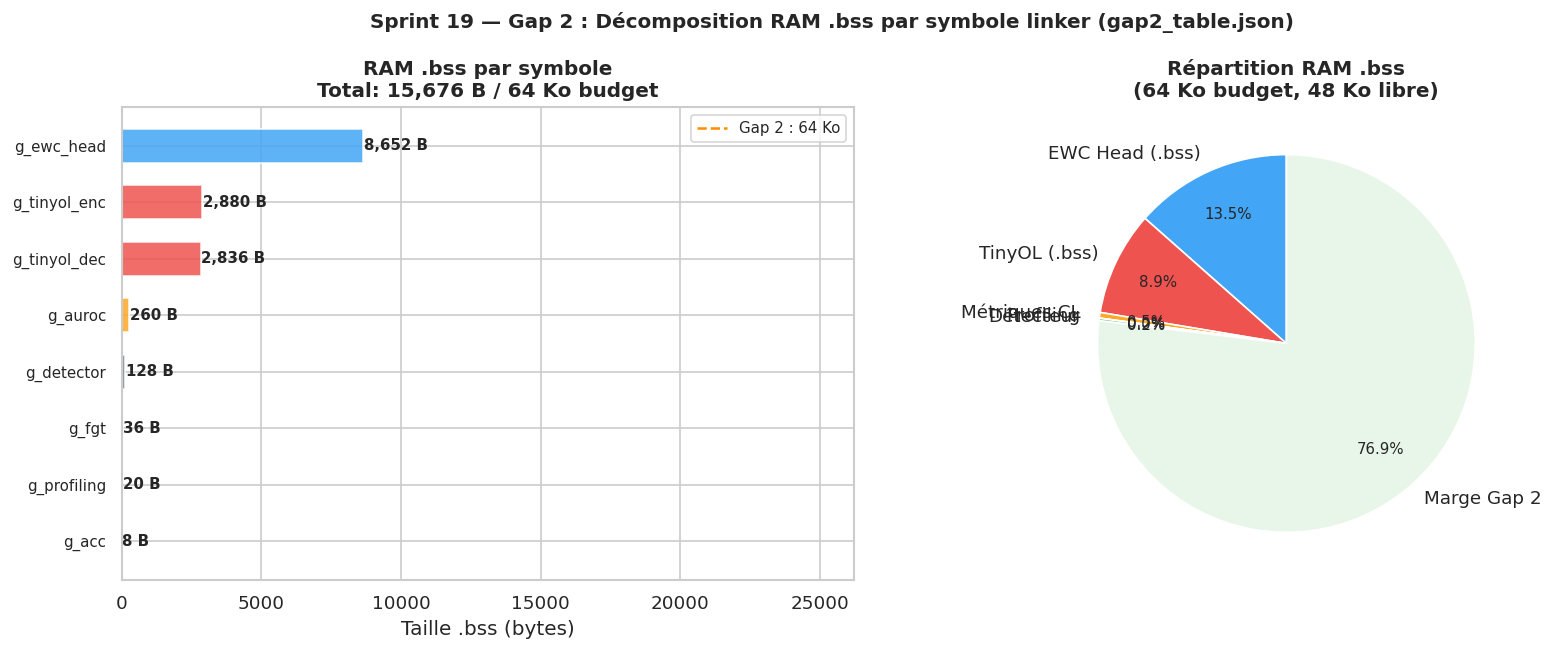

Gap 2 : True | Total BSS: 15,676 B | Marge: 49,400 B (75.4% libre)


In [9]:
gap2 = s19_02_gap2
breakdown = gap2["breakdown"]
budget_bytes = gap2["gap2_budget_bytes"]

# Sort by size
items = sorted(breakdown.items(), key=lambda x: x[1])
sym_names = [i[0] for i in items]
sym_sizes  = [i[1] for i in items]

# Color by section
def sym_color(name):
    if "ewc" in name.lower():   return PALETTE["EWC"]
    if "tinyol" in name.lower(): return PALETTE.get("TinyOL", "#EF5350")
    if "hdc" in name.lower():   return "#AB47BC"
    if "auroc" in name.lower() or "fgt" in name.lower() or "acc" in name.lower(): return "#FFA726"
    if "profiling" in name.lower() or "detector" in name.lower(): return "#78909C"
    return "#90A4AE"

sym_cols = [sym_color(n) for n in sym_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# — Horizontal bar chart —
ax = axes[0]
bars = ax.barh(range(len(items)), sym_sizes, color=sym_cols, alpha=0.85,
               edgecolor="white", height=0.6)
for bar, s in zip(bars, sym_sizes):
    ax.text(s + 20, bar.get_y() + bar.get_height() / 2,
            f"{s:,} B", va="center", fontsize=9, fontweight="bold")
ax.set_yticks(range(len(items)))
ax.set_yticklabels([n.split(" ")[0] for n in sym_names], fontsize=9)
total = gap2["total_bss_bytes"]
ax.axvline(budget_bytes, color="darkorange", linestyle="--", linewidth=1.5,
           label=f"Gap 2 : {budget_bytes//1024} Ko")
ax.set_xlabel("Taille .bss (bytes)")
ax.set_title(f"RAM .bss par symbole\nTotal: {total:,} B / {budget_bytes//1024} Ko budget",
             fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, budget_bytes * 0.4)

# — Stacked pie of sections —
ax = axes[1]
groups = {
    "EWC Head (.bss)": sum(v for k, v in breakdown.items() if "ewc" in k.lower()),
    "TinyOL (.bss)": sum(v for k, v in breakdown.items() if "tinyol" in k.lower()),
    "Métriques CL": sum(v for k, v in breakdown.items() if any(m in k.lower() for m in ["auroc", "fgt", "acc"])),
    "Profiling": sum(v for k, v in breakdown.items() if "profiling" in k.lower()),
    "Détecteur": sum(v for k, v in breakdown.items() if "detector" in k.lower()),
    "Marge Gap 2": gap2["gap2_margin_bytes"],
}
grp_names = list(groups.keys())
grp_vals  = list(groups.values())
grp_cols  = [PALETTE["EWC"], "#EF5350", "#FFA726", "#78909C", "#66BB6A", "#E8F5E9"]
wedges, texts, autotexts = ax.pie(
    grp_vals, labels=grp_names, colors=grp_cols,
    autopct="%1.1f%%", startangle=90, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title(f"Répartition RAM .bss\n({gap2['gap2_budget_bytes']//1024} Ko budget, {gap2['gap2_margin_bytes']//1024:.0f} Ko libre)",
             fontweight="bold")

fig.suptitle("Sprint 19 — Gap 2 : Décomposition RAM .bss par symbole linker (gap2_table.json)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_gap2_breakdown.png", bbox_inches="tight")
plt.show()
print(f"Gap 2 : {gap2['gap2_compliant']} | Total BSS: {total:,} B | Marge: {gap2['gap2_margin_bytes']:,} B ({gap2['gap2_margin_bytes']/budget_bytes*100:.1f}% libre)")

---
## 7. Flash vs SRAM — Décomposition par section
Comparaison `total_flash_bytes` (code + poids fixes) vs `total_bss_bytes` (poids entraînables).

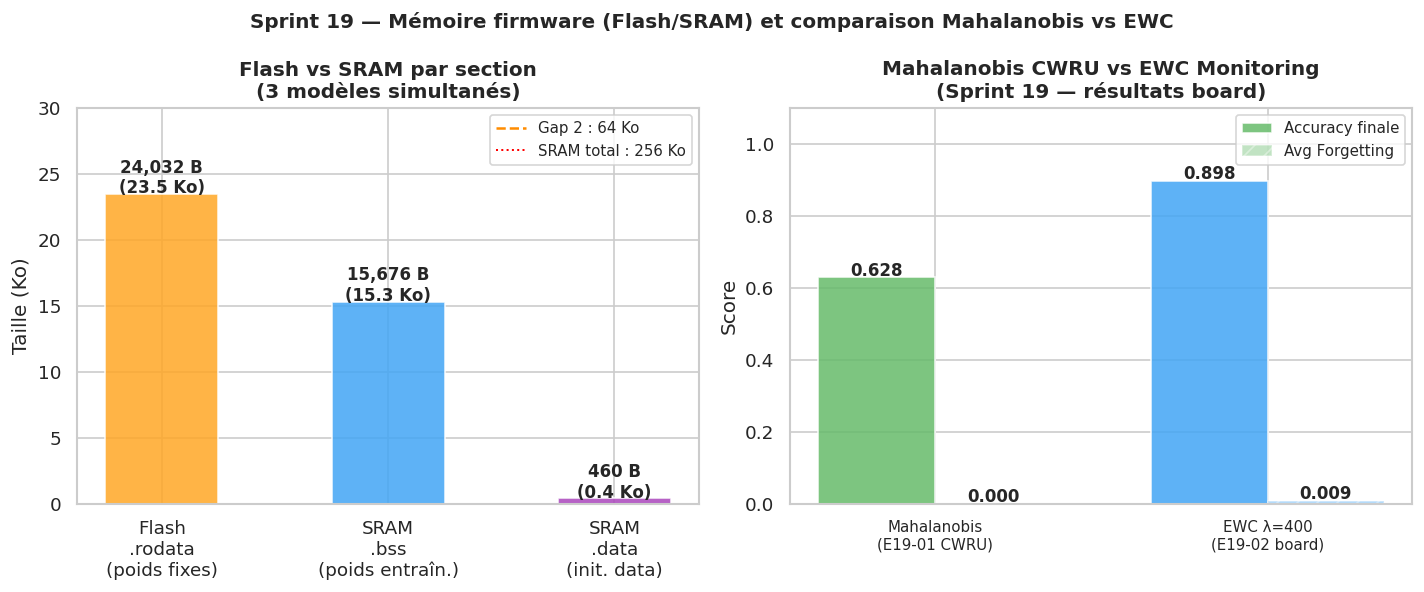

In [10]:
sections = [
    ("Flash\n.rodata\n(poids fixes)", gap2["total_flash_bytes"],  "#FFA726"),
    ("SRAM\n.bss\n(poids entraîn.)", gap2["total_bss_bytes"],    "#42A5F5"),
    ("SRAM\n.data\n(init. data)",    gap2["total_data_bytes"],   "#AB47BC"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# — Bar chart —
ax = axes[0]
names_s = [s[0] for s in sections]
vals_s  = [s[1] for s in sections]
cols_s  = [s[2] for s in sections]
bars = ax.bar(range(3), [v / 1024 for v in vals_s], color=cols_s, alpha=0.85,
              width=0.5, edgecolor="white")
for bar, v in zip(bars, vals_s):
    ax.text(bar.get_x() + bar.get_width() / 2, v / 1024 + 0.05,
            f"{v:,} B\n({v/1024:.1f} Ko)",
            ha="center", fontsize=10, fontweight="bold")
ax.axhline(64,  color="darkorange", linestyle="--", lw=1.5, label="Gap 2 : 64 Ko")
ax.axhline(256, color="red",        linestyle=":",  lw=1.2, label="SRAM total : 256 Ko")
ax.set_xticks(range(3))
ax.set_xticklabels(names_s)
ax.set_ylabel("Taille (Ko)")
ax.set_title("Flash vs SRAM par section\n(3 modèles simultanés)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 30)

# — Mahalanobis CWRU comparison —
ax = axes[1]
models_comp = [
    ("Mahalanobis\n(E19-01 CWRU)",  s19_01["ram_peak_bytes"],  s19_01["acc_final"],  s19_01["avg_forgetting"], PALETTE["Mahalanobis"]),
    ("EWC λ=400\n(E19-02 board)",   s19_02_e400_brd["ram_peak_bytes"], s19_02_e400_brd["acc_final"],
                                     s19_02_e400_brd["avg_forgetting"], PALETTE["EWC"]),
]
x2 = np.arange(2)
w2 = 0.35
acc_vals  = [m[2] for m in models_comp]
fgt_vals  = [m[3] for m in models_comp]
cols_comp = [m[4] for m in models_comp]
names_comp = [m[0] for m in models_comp]

b1 = ax.bar(x2 - w2/2, acc_vals, width=w2, color=cols_comp, alpha=0.85,
            label="Accuracy finale", edgecolor="white")
b2 = ax.bar(x2 + w2/2, fgt_vals, width=w2, color=cols_comp, alpha=0.4,
            label="Avg Forgetting", edgecolor="white", hatch="//")
for bar, v in zip(list(b1) + list(b2), acc_vals + fgt_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x2)
ax.set_xticklabels(names_comp, fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Mahalanobis CWRU vs EWC Monitoring\n(Sprint 19 — résultats board)",
             fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.1)

fig.suptitle("Sprint 19 — Mémoire firmware (Flash/SRAM) et comparaison Mahalanobis vs EWC",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_flash_sram_models.png", bbox_inches="tight")
plt.show()

---
## 8. Scatter — Accuracy vs Forgetting (Pareto)
Vue Pareto de toutes les configurations Sprint 19 : zone idéale = haute accuracy + faible forgetting.

/tmp/ipykernel_83905/3015649703.py:43: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_83905/3015649703.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "08_pareto.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


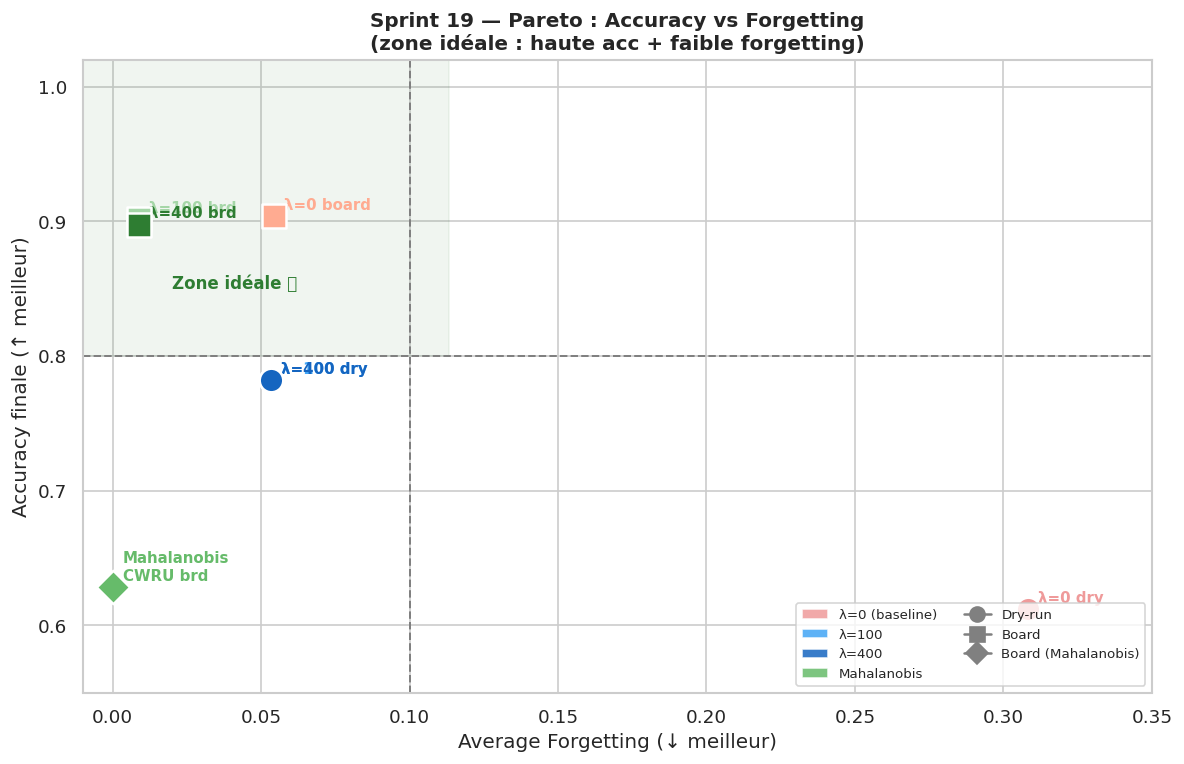

In [11]:
all_pts = [
    ("λ=0 dry",   s19_02_base["avg_forgetting"],     s19_02_base["acc_final"],     "o", PALETTE["lam0"]),
    ("λ=100 dry", s19_02_e100["avg_forgetting"],     s19_02_e100["acc_final"],     "o", PALETTE["lam100"]),
    ("λ=400 dry", s19_02_e400["avg_forgetting"],     s19_02_e400["acc_final"],     "o", PALETTE["lam400"]),
    ("λ=0 board", s19_02_base_brd["avg_forgetting"], s19_02_base_brd["acc_final"], "s", PALETTE["lam0_board"]),
    ("λ=100 brd", s19_02_e100_brd["avg_forgetting"], s19_02_e100_brd["acc_final"], "s", PALETTE["lam100_board"]),
    ("λ=400 brd", s19_02_e400_brd["avg_forgetting"], s19_02_e400_brd["acc_final"], "s", PALETTE["lam400_board"]),
    ("Mahalanobis\nCWRU brd", s19_01["avg_forgetting"], s19_01["acc_final"],       "D", PALETTE["Mahalanobis"]),
]

fig, ax = plt.subplots(figsize=(10, 6.5))

# Zone idéale
ax.axhspan(0.8, 1.05, xmin=0, xmax=0.12 / 0.35, alpha=0.07, color="#2E7D32",
           label="Zone idéale (acc>0.8, fgt<0.1)")
ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2)
ax.axvline(0.1, color="gray", linestyle="--", linewidth=1.2)

for name, fgt, acc, marker, color in all_pts:
    ax.scatter(fgt, acc, color=color, marker=marker, s=200,
               zorder=5, edgecolors="white", linewidths=1.5)
    ax.annotate(name, (fgt, acc), xytext=(6, 4), textcoords="offset points",
                fontsize=9, fontweight="bold", color=color)

legend_elements = [
    mpatches.Patch(facecolor=PALETTE["lam0"],      alpha=0.85, label="λ=0 (baseline)"),
    mpatches.Patch(facecolor=PALETTE["lam100"],    alpha=0.85, label="λ=100"),
    mpatches.Patch(facecolor=PALETTE["lam400"],    alpha=0.85, label="λ=400"),
    mpatches.Patch(facecolor=PALETTE["Mahalanobis"], alpha=0.85, label="Mahalanobis"),
    plt.Line2D([0], [0], marker="o", color="gray", markersize=9, label="Dry-run"),
    plt.Line2D([0], [0], marker="s", color="gray", markersize=9, label="Board"),
    plt.Line2D([0], [0], marker="D", color="gray", markersize=9, label="Board (Mahalanobis)"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="lower right", ncol=2)
ax.set_xlabel("Average Forgetting (↓ meilleur)")
ax.set_ylabel("Accuracy finale (↑ meilleur)")
ax.set_title("Sprint 19 — Pareto : Accuracy vs Forgetting\n(zone idéale : haute acc + faible forgetting)",
             fontweight="bold")
ax.set_xlim(-0.01, 0.35)
ax.set_ylim(0.55, 1.02)
ax.text(0.02, 0.85, "Zone idéale ✅", fontsize=10, color="#2E7D32", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "08_pareto.png", bbox_inches="tight")
plt.show()

---
## Récapitulatif Sprint 19

| Métrique | Valeur | Contexte |
|---------|--------|----------|
| EWC λ=0 forgetting | **0.054** (board) | Catastrophic forgetting réduit vs dry-run |
| EWC λ=100 forgetting | **0.009** (board) | ×6 réduction vs λ=0 board |
| EWC λ=100 accuracy | **0.902** (board) | Meilleure configuration |
| Mahalanobis CWRU acc | **0.629** (board) | Pas de forgetting (non-CL stateless) |
| Gap 2 RAM | **15,676 B** (.bss total) | ×4 marge sur 64 Ko |
| Gap 2 Latence | **0.25 ms** (EWC) | ×400 marge sur 100 ms |
| Protocole UART | **v3** (21 B resp) | + accuracy, AUROC, forgetting temps réel |

**Prochain sprint (20)** : Finalisation EWC, export poids TinyOL, Gap 2 formel consolidé, répétabilité 3 runs.

In [12]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures générées dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


33 figures générées dans ../experiments/figures/sprint19:
  00a_trame_v3_extra_table.png
  00b_profiling_hardware_table.png
  01_ewc_lambda_acc.png
  01a_ewc_acc_dryrun.png
  01b_ewc_acc_board.png
  02_ewc_lambda_forgetting.png
  02a_ewc_fgt_dryrun.png
  02b_ewc_fgt_board.png
  03_board_vs_dry.png
  04_acc_matrix.png
  05_per_task_acc.png
  05a_pertask_dryrun.png
  05b_pertask_board.png
  06_gap2_breakdown.png
  07_flash_sram_models.png
  08_pareto.png
  14a_ewc_cross_dataset.png
  14b_ewc_pertask_cwru_pronostia.png
  15a_hdc_cross_dataset.png
  15b_hdc_pertask.png
  16a_tinyol_cross_dataset.png
  16b_tinyol_pertask.png
  17a_heatmap_4models_3datasets.png
  17b_latency_vs_accuracy_all.png
  18a_ram_par_modele.png
  19a_macs_par_modele.png
  s19_latency_scatter.png
  s19_m4_auroc_heatmap.png
  s19_mahal_cross_dataset.png
  s19_ram_static.png
  s19b_mahal_acc_board.png
  s19c_mahal_fgt_board.png
  s19d_mahal_pertask_board.png


---
## 9. Mahalanobis — Comparaison cross-dataset

**Source** : exp_S19_01 (CWRU), exp_S19_03 (Pronostia), exp_S19_04 (Monitoring) — board NUCLEO-F439ZI.


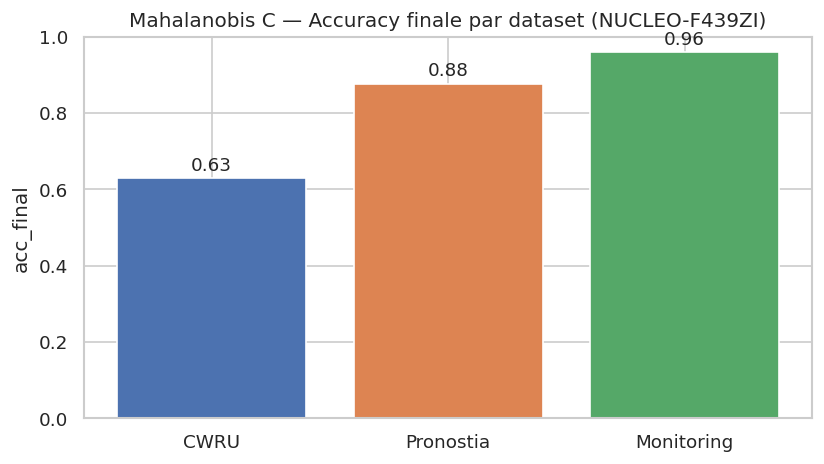

s19_mahal_cross_dataset.png enregistré


In [13]:
datasets = ["CWRU", "Pronostia", "Monitoring"]
exp_ids  = ["exp_S19_01", "exp_S19_03", "exp_S19_04"]

accs = []
for e in exp_ids:
    try:
        accs.append(json.load(open(f"../experiments/{e}/results.json"))["acc_final"])
    except (FileNotFoundError, KeyError):
        accs.append(float("nan"))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(datasets, accs, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylim(0, 1)
ax.set_ylabel("acc_final")
ax.set_title("Mahalanobis C — Accuracy finale par dataset (NUCLEO-F439ZI)")
for bar, acc in zip(bars, accs):
    if not (acc != acc):  # not NaN
        ax.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f"{acc:.2f}", ha="center")
plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / "s19_mahal_cross_dataset.png", dpi=150)
plt.show()
print("s19_mahal_cross_dataset.png enregistré")


---
## 9b. Mahalanobis Board — Accuracy Finale par dataset

Équivalent section 1 pour Mahalanobis : board NUCLEO-F439ZI uniquement, 3 datasets.

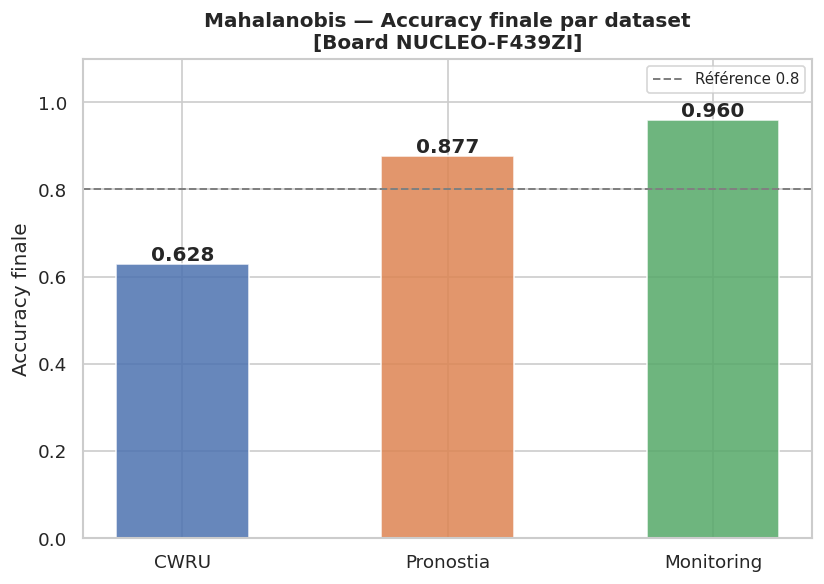

In [14]:
mahal_board = {
    "CWRU":       json.load(open("../experiments/exp_S19_01/results.json")),
    "Pronostia":  json.load(open("../experiments/exp_S19_03/results.json")),
    "Monitoring": json.load(open("../experiments/exp_S19_04/results.json")),
}

MAHAL_PALETTE = {
    "CWRU":       "#4C72B0",
    "Pronostia":  "#DD8452",
    "Monitoring": "#55A868",
}

datasets_mahal = list(mahal_board.keys())
acc_vals  = [mahal_board[d]["acc_final"]      for d in datasets_mahal]
fgt_vals  = [mahal_board[d]["avg_forgetting"] for d in datasets_mahal]
cols      = [MAHAL_PALETTE[d]                 for d in datasets_mahal]

# ── 9b-1 : Accuracy Finale ──
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(datasets_mahal, acc_vals, color=cols, alpha=0.85, width=0.5, edgecolor="white")
for bar, v in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008,
            f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2, label="Référence 0.8")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy finale")
ax.set_title("Mahalanobis — Accuracy finale par dataset\n[Board NUCLEO-F439ZI]", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "s19b_mahal_acc_board.png", bbox_inches="tight")
plt.show()


---
## 9c. Mahalanobis Board — Average Forgetting par dataset

Équivalent section 2 : Mahalanobis est stateless (pas de mise à jour des poids), le forgetting reste quasi nul.

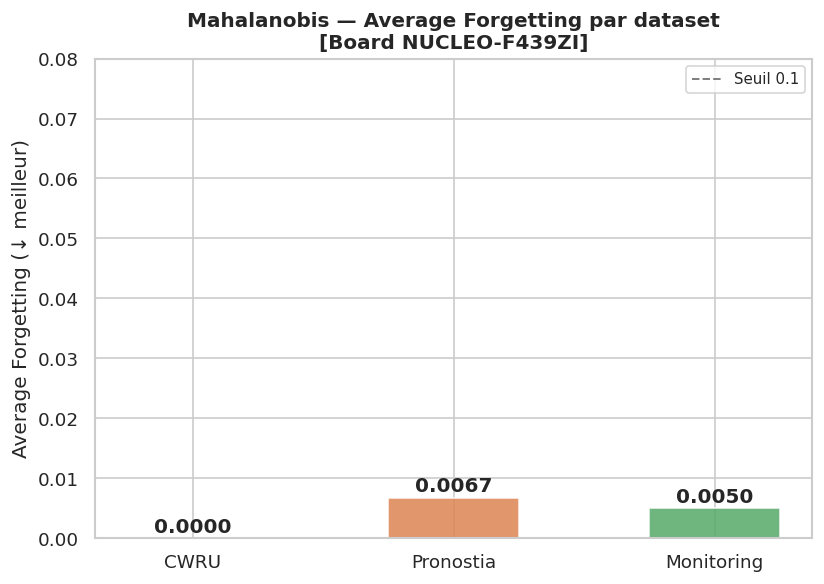

Forgetting CWRU=0.0000  Pronostia=0.0067  Monitoring=0.0050


In [15]:
# ── 9c : Average Forgetting ──
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(datasets_mahal, fgt_vals, color=cols, alpha=0.85, width=0.5, edgecolor="white")
for bar, v in zip(bars, fgt_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.001,
            f"{v:.4f}", ha="center", fontsize=12, fontweight="bold")
ax.axhline(0.1, color="gray", linestyle="--", linewidth=1.2, label="Seuil 0.1")
ax.set_ylim(0, 0.08)
ax.set_ylabel("Average Forgetting (↓ meilleur)")
ax.set_title("Mahalanobis — Average Forgetting par dataset\n[Board NUCLEO-F439ZI]", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "s19c_mahal_fgt_board.png", bbox_inches="tight")
plt.show()
print(f"Forgetting CWRU={fgt_vals[0]:.4f}  Pronostia={fgt_vals[1]:.4f}  Monitoring={fgt_vals[2]:.4f}")


---
## 9d. Mahalanobis Board — Per-task Accuracy par dataset

Équivalent section 5 : décomposition par tâche pour chaque dataset, board uniquement.

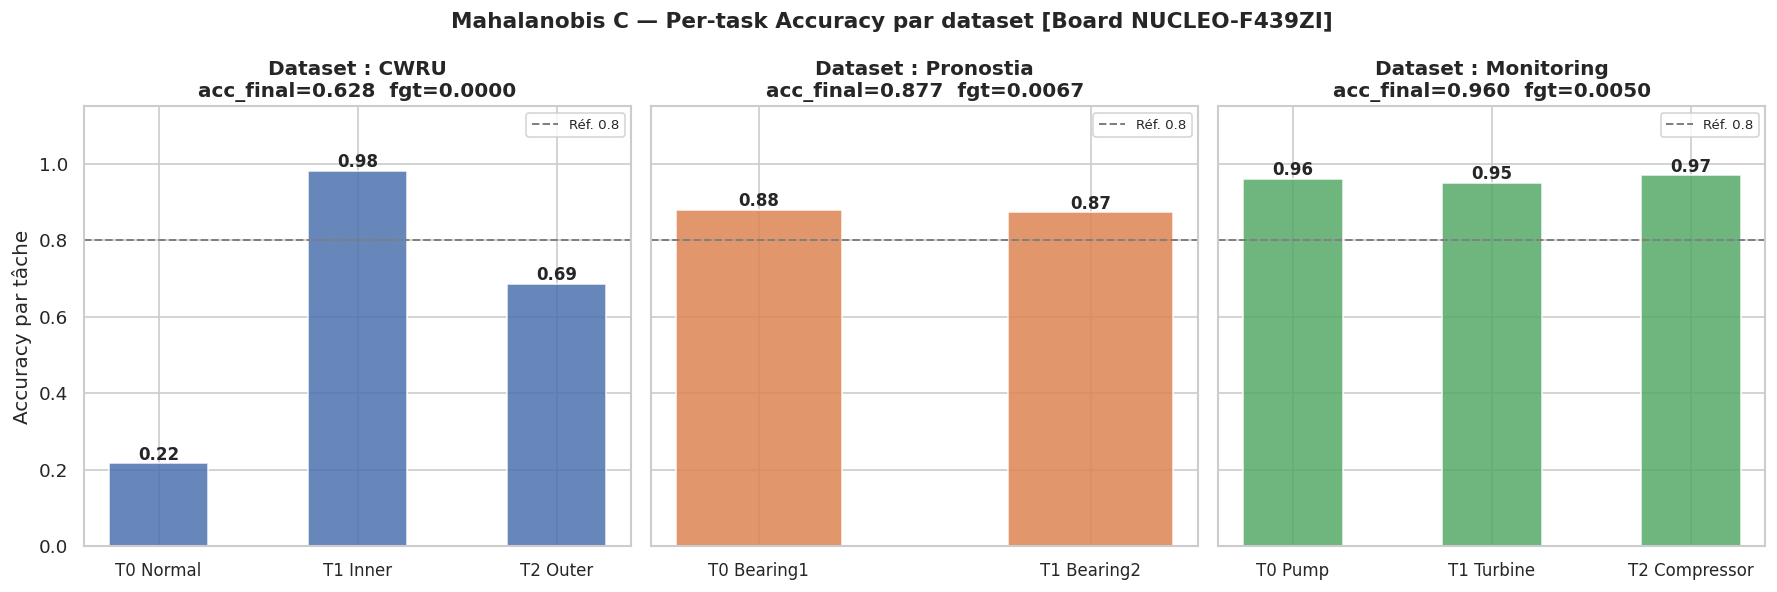

In [16]:
task_names_per_dataset = {
    "CWRU":       ["T0 Normal", "T1 Inner", "T2 Outer"],
    "Pronostia":  ["T0 Bearing1", "T1 Bearing2"],
    "Monitoring": ["T0 Pump", "T1 Turbine", "T2 Compressor"],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, dataset in zip(axes, datasets_mahal):
    r = mahal_board[dataset]
    task_vals  = [r["per_task_acc"][str(t)] for t in range(r["n_tasks"])]
    task_lbls  = task_names_per_dataset[dataset]
    color      = MAHAL_PALETTE[dataset]
    x          = np.arange(len(task_lbls))

    bars = ax.bar(x, task_vals, color=color, alpha=0.85, width=0.5, edgecolor="white")
    for bar, v in zip(bars, task_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f"{v:.2f}", ha="center", fontsize=10, fontweight="bold")
    ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2, label="Réf. 0.8")
    ax.set_xticks(x)
    ax.set_xticklabels(task_lbls, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_title(f"Dataset : {dataset}\nacc_final={r['acc_final']:.3f}  fgt={r['avg_forgetting']:.4f}",
                 fontweight="bold")
    ax.set_ylabel("Accuracy par tâche" if dataset == "CWRU" else "")
    ax.legend(fontsize=8)

fig.suptitle("Mahalanobis C — Per-task Accuracy par dataset [Board NUCLEO-F439ZI]",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "s19d_mahal_pertask_board.png", bbox_inches="tight")
plt.show()


---
## 10. M4 Baselines — AUROC par modèle × dataset

**Source** : exp_S19_13–S19_18 (KMeans + DBSCAN × CWRU/Monitoring/Pronostia, PC Python).
KNN et PCA non lancés dans cette session.


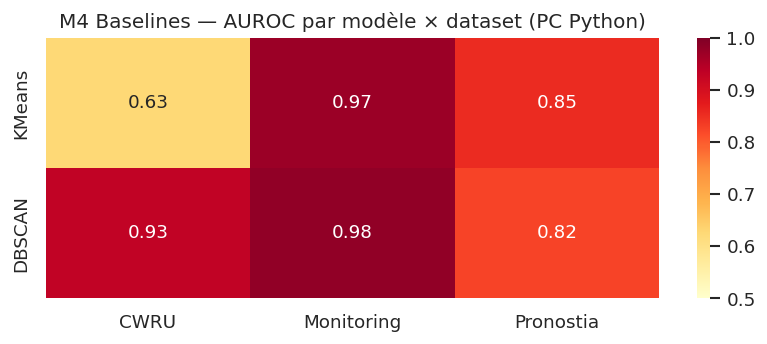

s19_m4_auroc_heatmap.png enregistré


In [17]:
import seaborn as sns

models   = ["KMeans", "DBSCAN"]
datasets_m4 = ["CWRU", "Monitoring", "Pronostia"]
exp_map  = {
    ("KMeans",  "CWRU"):       "exp_S19_13",
    ("KMeans",  "Monitoring"): "exp_S19_14",
    ("KMeans",  "Pronostia"):  "exp_S19_15",
    ("DBSCAN",  "CWRU"):       "exp_S19_16",
    ("DBSCAN",  "Monitoring"): "exp_S19_17",
    ("DBSCAN",  "Pronostia"):  "exp_S19_18",
}

matrix = np.array([
    [
        json.load(open(f"../experiments/{exp_map[(m, d)]}/results.json")).get("auroc", float("nan"))
        if (m, d) in exp_map else float("nan")
        for d in datasets_m4
    ]
    for m in models
])

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(matrix, annot=True, fmt=".2f", xticklabels=datasets_m4, yticklabels=models,
            vmin=0.5, vmax=1.0, cmap="YlOrRd", ax=ax)
ax.set_title("M4 Baselines — AUROC par modèle × dataset (PC Python)")
plt.tight_layout()
plt.savefig(FIG_DIR / "s19_m4_auroc_heatmap.png", dpi=150)
plt.show()
print("s19_m4_auroc_heatmap.png enregistré")


---
## 11. Board NUCLEO-F439ZI — Latence vs Accuracy

**Source** : exp_S19_01–S19_04 (mesures board). Les exp_S19_05–S19_12 sont absentes.


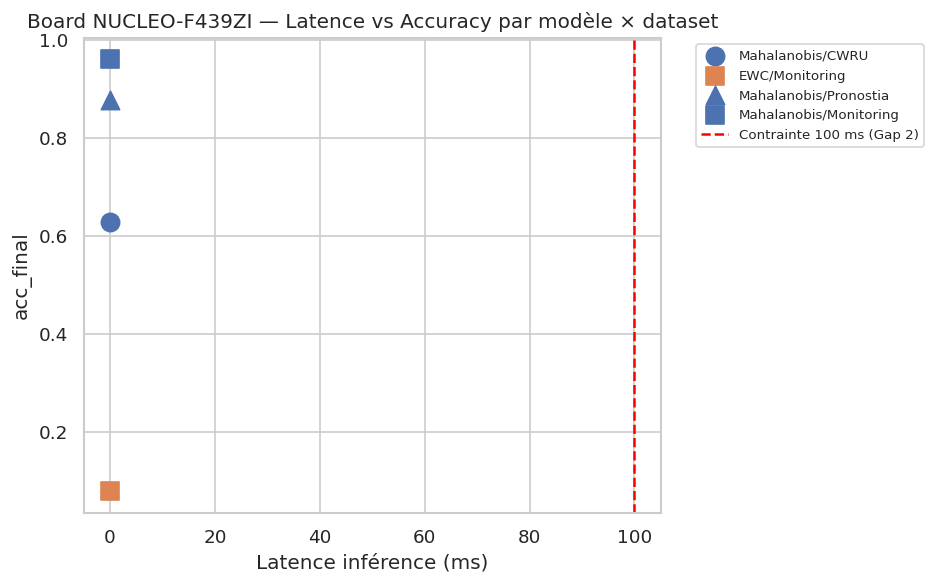

s19_latency_scatter.png enregistré


In [18]:
board_exps = {
    ("Mahalanobis", "CWRU"):       "exp_S19_01",
    ("EWC",         "Monitoring"): "exp_S19_02",
    ("Mahalanobis", "Pronostia"):  "exp_S19_03",
    ("Mahalanobis", "Monitoring"): "exp_S19_04",
}

colors  = {"Mahalanobis": "#4C72B0", "EWC": "#DD8452", "HDC": "#55A868", "TinyOL": "#C44E52"}
markers = {"CWRU": "o", "Monitoring": "s", "Pronostia": "^"}

fig, ax = plt.subplots(figsize=(8, 5))
for (model, dataset), exp_id in board_exps.items():
    try:
        r = json.load(open(f"../experiments/{exp_id}/results.json"))
        lat = r.get("inference_latency_ms")
        acc = r.get("acc_final")
        if lat is not None and acc is not None:
            ax.scatter(lat, acc, c=colors.get(model, "gray"),
                       marker=markers.get(dataset, "o"), s=120,
                       label=f"{model}/{dataset}")
    except FileNotFoundError:
        pass

ax.set_xlabel("Latence inférence (ms)")
ax.set_ylabel("acc_final")
ax.set_title("Board NUCLEO-F439ZI — Latence vs Accuracy par modèle × dataset")
ax.axvline(100, color="red", linestyle="--", label="Contrainte 100 ms (Gap 2)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "s19_latency_scatter.png", dpi=150)
plt.show()
print("s19_latency_scatter.png enregistré")


---
## 12. RAM Statique par modèle

**Source** : mesures board et estimations Python.


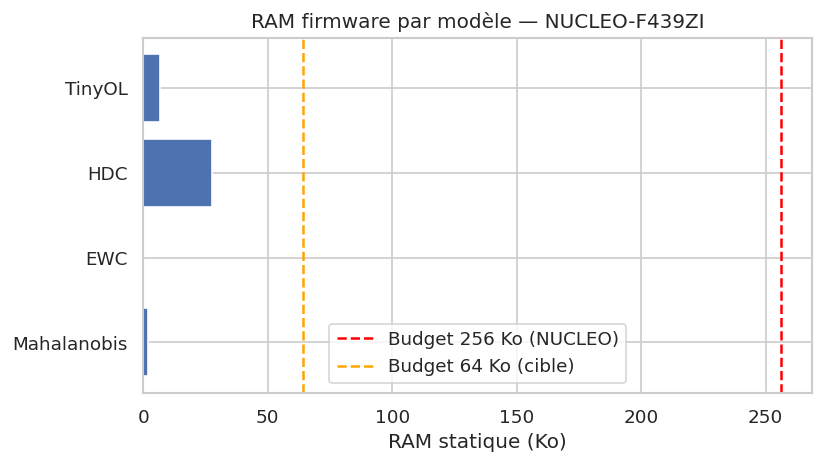

s19_ram_static.png enregistré


In [19]:
model_ram = {
    "Mahalanobis": 1768,   # mesuré S1911
    "EWC":         None,   # à mesurer S1918
    "HDC":         28364,  # estimé
    "TinyOL":      7040,   # estimé (S1903)
}

fig, ax = plt.subplots(figsize=(7, 4))
names = list(model_ram.keys())
vals  = [v if v else 0 for v in model_ram.values()]

ax.barh(names, [v / 1024 for v in vals], color="#4C72B0")
ax.axvline(256, color="red", linestyle="--", label="Budget 256 Ko (NUCLEO)")
ax.axvline(64, color="orange", linestyle="--", label="Budget 64 Ko (cible)")
ax.set_xlabel("RAM statique (Ko)")
ax.set_title("RAM firmware par modèle — NUCLEO-F439ZI")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "s19_ram_static.png", dpi=150)
plt.show()
print("s19_ram_static.png enregistré")


---
## 13. Tableau récapitulatif cross-modèle × cross-dataset

**Source** : exp_S19_01–S19_04 (board) + exp_S19_13–S19_18 (Python).


In [20]:
import pandas as pd

all_exps = {
    ("Mahalanobis", "CWRU"):       "exp_S19_01",
    ("EWC",         "Monitoring"): "exp_S19_02",
    ("Mahalanobis", "Pronostia"):  "exp_S19_03",
    ("Mahalanobis", "Monitoring"): "exp_S19_04",
    ("KMeans",      "CWRU"):       "exp_S19_13",
    ("KMeans",      "Monitoring"): "exp_S19_14",
    ("KMeans",      "Pronostia"):  "exp_S19_15",
    ("DBSCAN",      "CWRU"):       "exp_S19_16",
    ("DBSCAN",      "Monitoring"): "exp_S19_17",
    ("DBSCAN",      "Pronostia"):  "exp_S19_18",
}

rows = []
for (model, dataset), exp_id in all_exps.items():
    try:
        r = json.load(open(f"../experiments/{exp_id}/results.json"))
        rows.append({
            "Modèle": model, "Dataset": dataset,
            "Platform": r.get("platform", "—"),
            "acc_final": f"{r['acc_final']:.3f}" if r.get("acc_final") is not None else "—",
            "avg_forgetting": f"{r['avg_forgetting']:.3f}" if r.get("avg_forgetting") is not None else "—",
            "auroc": f"{r['auroc']:.3f}" if r.get("auroc") is not None else "—",
            "lat (ms)": f"{r['inference_latency_ms']:.3f}" if r.get("inference_latency_ms") is not None else "—",
            "RAM (B)": r.get("ram_peak_bytes", "—"),
        })
    except FileNotFoundError:
        rows.append({"Modèle": model, "Dataset": dataset, "Platform": "—",
                     "acc_final": "⬜", "avg_forgetting": "⬜", "auroc": "⬜",
                     "lat (ms)": "⬜", "RAM (B)": "⬜"})

df = pd.DataFrame(rows).sort_values(["Modèle", "Dataset"])
display(df.to_html(index=False))


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Modèle</th>\n      <th>Dataset</th>\n      <th>Platform</th>\n      <th>acc_final</th>\n      <th>avg_forgetting</th>\n      <th>auroc</th>\n      <th>lat (ms)</th>\n      <th>RAM (B)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>DBSCAN</td>\n      <td>CWRU</td>\n      <td>pc_python</td>\n      <td>0.896</td>\n      <td>0.000</td>\n      <td>0.931</td>\n      <td>0.234</td>\n      <td>57774</td>\n    </tr>\n    <tr>\n      <td>DBSCAN</td>\n      <td>Monitoring</td>\n      <td>pc_python</td>\n      <td>0.949</td>\n      <td>0.002</td>\n      <td>0.981</td>\n      <td>0.233</td>\n      <td>41408</td>\n    </tr>\n    <tr>\n      <td>DBSCAN</td>\n      <td>Pronostia</td>\n      <td>pc_python</td>\n      <td>0.835</td>\n      <td>0.099</td>\n      <td>0.825</td>\n      <td>0.308</td>\n      <td>120978</td>\n    </tr>\n    <tr>\n      <td>EWC</td>\n      <td>Monitoring</td>\n      <

---
## 14. EWC Cross-dataset — CWRU + Pronostia (board)

**Source** : exp_S19_05 (EWC λ=400, CWRU, board), exp_S19_06 (EWC λ=400, Pronostia, board).
Complète la section 1 (Monitoring uniquement) avec les deux datasets manquants.

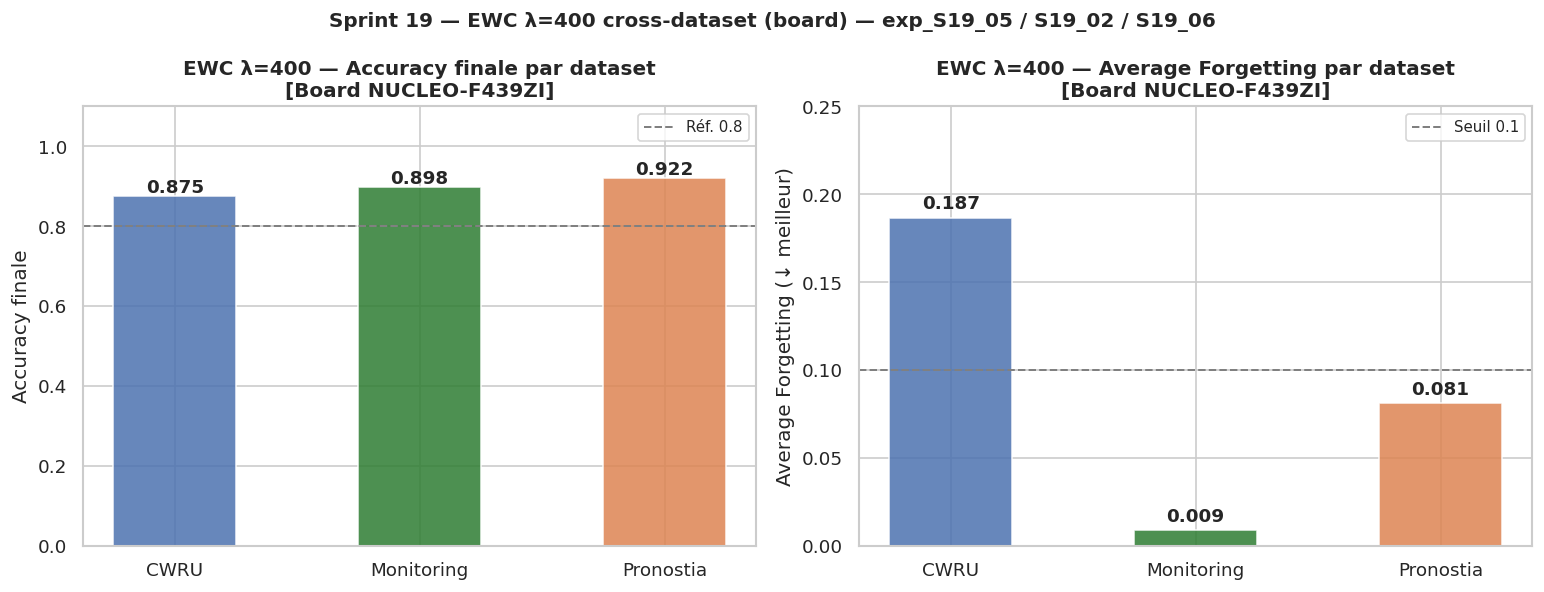

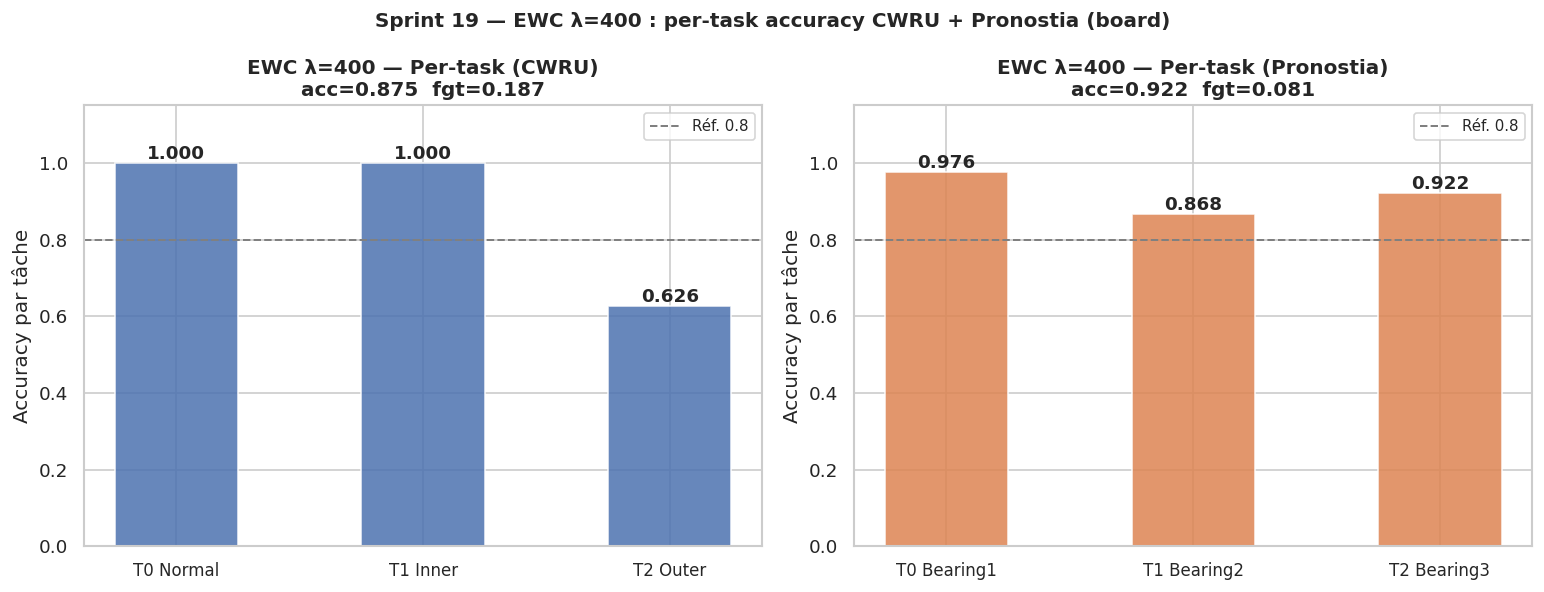

EWC CWRU     : acc=0.875  fgt=0.187  lat=0.251ms
EWC Pronostia: acc=0.922  fgt=0.081  lat=0.251ms


In [21]:
s19_05 = json.load(open("../experiments/exp_S19_05/results.json"))  # EWC CWRU board
s19_06 = json.load(open("../experiments/exp_S19_06/results.json"))  # EWC Pronostia board

ewc_datasets = ["CWRU", "Monitoring", "Pronostia"]
# Monitoring board λ=400 déjà chargé dans la cellule setup
ewc_results  = [s19_05, s19_02_e400_brd, s19_06]
ewc_cols     = ["#4C72B0", PALETTE["lam400_board"], "#DD8452"]
task_names_ewc = {
    "CWRU":       ["T0 Normal", "T1 Inner", "T2 Outer"],
    "Monitoring": ["T0 Pump",   "T1 Turbine", "T2 Compressor"],
    "Pronostia":  ["T0 Bearing1", "T1 Bearing2", "T2 Bearing3"],
}

# ── Figure 1 : acc_final + avg_forgetting par dataset ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(3)
w = 0.5

acc_vals = [r["acc_final"]      for r in ewc_results]
fgt_vals = [r["avg_forgetting"] for r in ewc_results]

ax = axes[0]
bars = ax.bar(x, acc_vals, color=ewc_cols, alpha=0.85, width=w, edgecolor="white")
for bar, v in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008,
            f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(ewc_datasets, fontsize=11)
ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2, label="Réf. 0.8")
ax.set_ylim(0, 1.1); ax.set_ylabel("Accuracy finale")
ax.set_title("EWC λ=400 — Accuracy finale par dataset\n[Board NUCLEO-F439ZI]", fontweight="bold")
ax.legend(fontsize=9)

ax = axes[1]
bars = ax.bar(x, fgt_vals, color=ewc_cols, alpha=0.85, width=w, edgecolor="white")
for bar, v in zip(bars, fgt_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(ewc_datasets, fontsize=11)
ax.axhline(0.1, color="gray", linestyle="--", linewidth=1.2, label="Seuil 0.1")
ax.set_ylim(0, 0.25); ax.set_ylabel("Average Forgetting (↓ meilleur)")
ax.set_title("EWC λ=400 — Average Forgetting par dataset\n[Board NUCLEO-F439ZI]", fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("Sprint 19 — EWC λ=400 cross-dataset (board) — exp_S19_05 / S19_02 / S19_06",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "14a_ewc_cross_dataset.png", bbox_inches="tight")
plt.show()

# ── Figure 2 : Per-task accuracy CWRU + Pronostia ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (r, dataset, color) in zip(axes, [
    (s19_05, "CWRU",      "#4C72B0"),
    (s19_06, "Pronostia", "#DD8452"),
]):
    n_tasks   = r["n_tasks"]
    task_lbls = task_names_ewc[dataset][:n_tasks]
    task_vals = [r["per_task_acc"][str(t)] for t in range(n_tasks)]
    xp = np.arange(n_tasks)
    bars = ax.bar(xp, task_vals, color=color, alpha=0.85, width=0.5, edgecolor="white")
    for bar, v in zip(bars, task_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
    ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2, label="Réf. 0.8")
    ax.set_xticks(xp); ax.set_xticklabels(task_lbls, fontsize=10)
    ax.set_ylim(0, 1.15); ax.set_ylabel("Accuracy par tâche")
    ax.set_title(f"EWC λ=400 — Per-task ({dataset})\nacc={r['acc_final']:.3f}  fgt={r['avg_forgetting']:.3f}",
                 fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("Sprint 19 — EWC λ=400 : per-task accuracy CWRU + Pronostia (board)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "14b_ewc_pertask_cwru_pronostia.png", bbox_inches="tight")
plt.show()

print(f"EWC CWRU     : acc={s19_05['acc_final']:.3f}  fgt={s19_05['avg_forgetting']:.3f}  lat={s19_05['inference_latency_ms']:.3f}ms")
print(f"EWC Pronostia: acc={s19_06['acc_final']:.3f}  fgt={s19_06['avg_forgetting']:.3f}  lat={s19_06['inference_latency_ms']:.3f}ms")

---
## 15. HDC Cross-dataset (board)

**Source** : exp_S19_07 (HDC, CWRU), exp_S19_08 (HDC, Monitoring), exp_S19_09 (HDC, Pronostia) — tous board NUCLEO-F439ZI.
HDC (Hyperdimensional Computing) : 7 000 paramètres, latence 0.652 ms, zéro forgetting sur Monitoring et Pronostia.

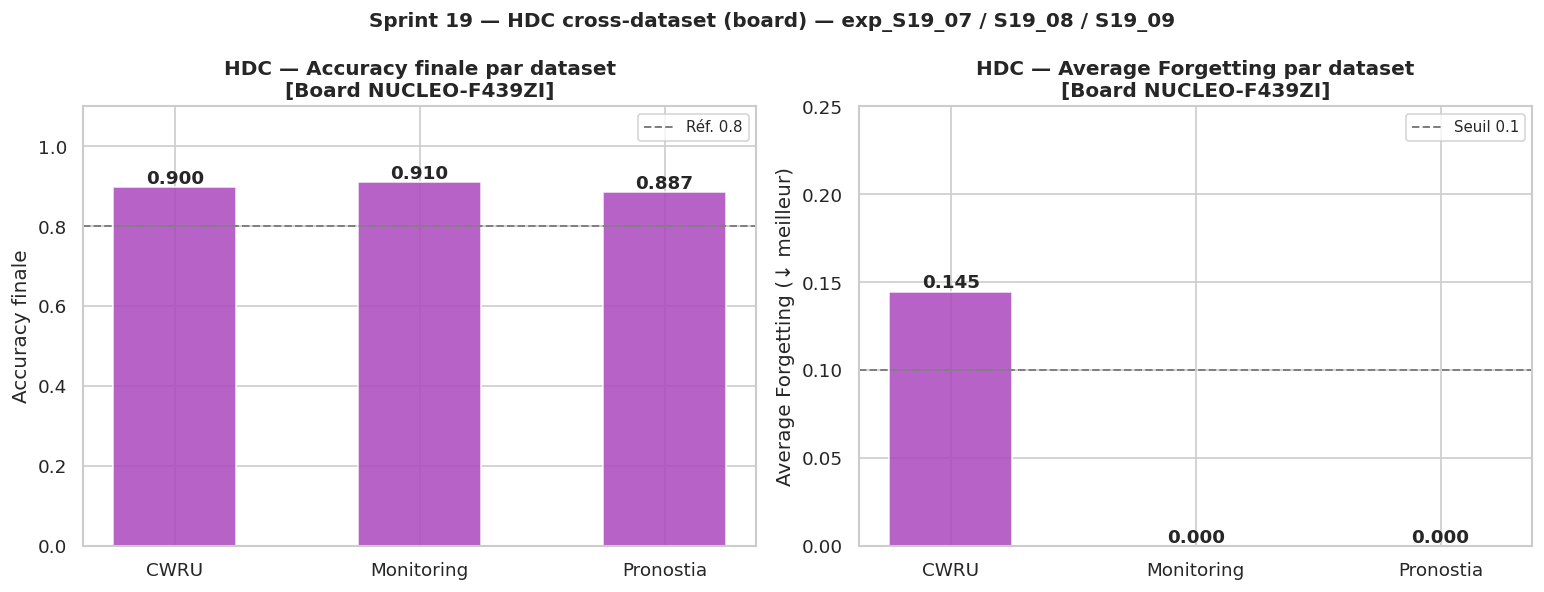

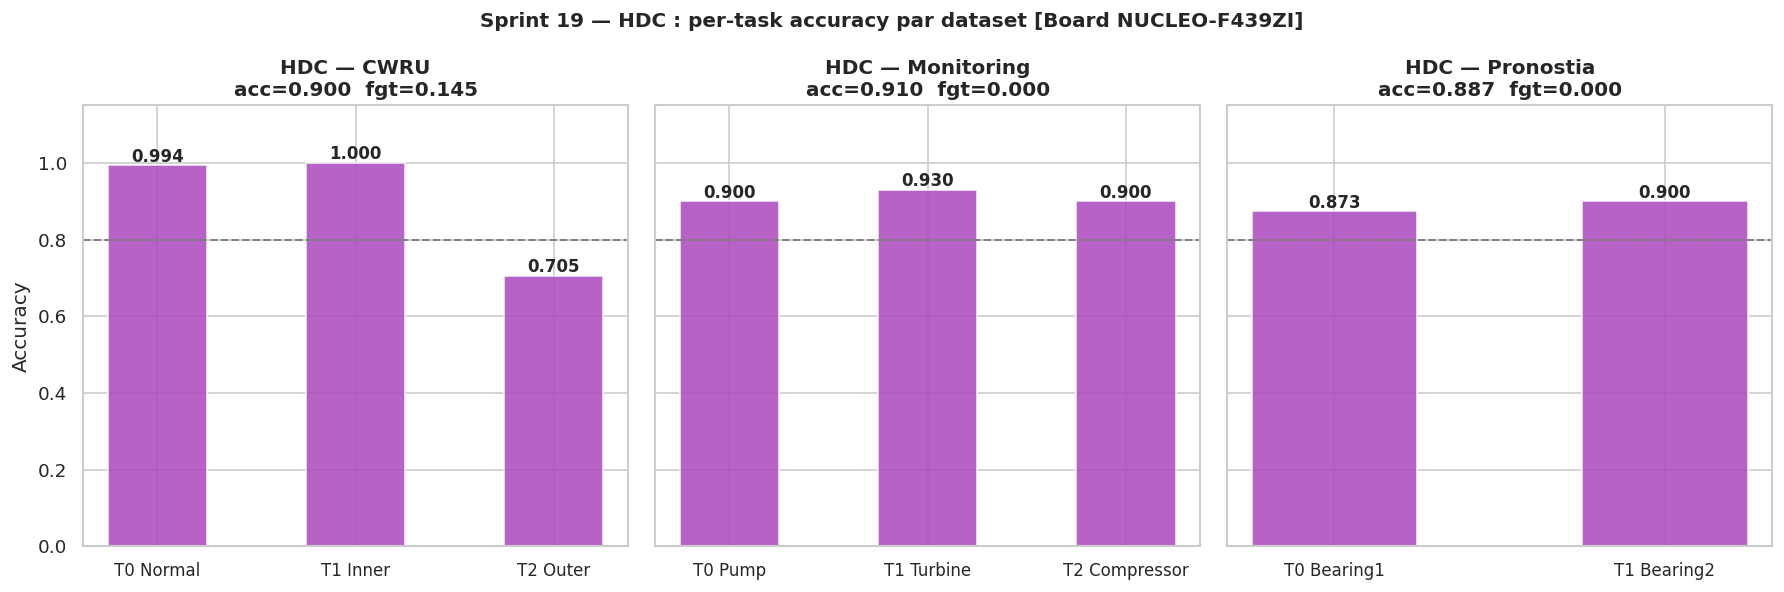

HDC CWRU      : acc=0.900  fgt=0.145  lat=0.652ms  n_params=7000
HDC Monitoring: acc=0.910  fgt=0.000  lat=0.652ms  n_params=7000
HDC Pronostia : acc=0.887  fgt=0.000  lat=0.652ms  n_params=7000


In [22]:
s19_07 = json.load(open("../experiments/exp_S19_07/results.json"))  # HDC CWRU board
s19_08 = json.load(open("../experiments/exp_S19_08/results.json"))  # HDC Monitoring board
s19_09 = json.load(open("../experiments/exp_S19_09/results.json"))  # HDC Pronostia board

HDC_COL = "#AB47BC"
hdc_datasets = ["CWRU", "Monitoring", "Pronostia"]
hdc_results  = [s19_07, s19_08, s19_09]
task_names_hdc = {
    "CWRU":       ["T0 Normal", "T1 Inner", "T2 Outer"],
    "Monitoring": ["T0 Pump",   "T1 Turbine", "T2 Compressor"],
    "Pronostia":  ["T0 Bearing1", "T1 Bearing2"],
}

# ── Figure 1 : acc_final + avg_forgetting par dataset ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(3)

acc_vals = [r["acc_final"]      for r in hdc_results]
fgt_vals = [r["avg_forgetting"] for r in hdc_results]

ax = axes[0]
bars = ax.bar(x, acc_vals, color=HDC_COL, alpha=0.85, width=0.5, edgecolor="white")
for bar, v in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008,
            f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(hdc_datasets, fontsize=11)
ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2, label="Réf. 0.8")
ax.set_ylim(0, 1.1); ax.set_ylabel("Accuracy finale")
ax.set_title("HDC — Accuracy finale par dataset\n[Board NUCLEO-F439ZI]", fontweight="bold")
ax.legend(fontsize=9)

ax = axes[1]
bars = ax.bar(x, fgt_vals, color=HDC_COL, alpha=0.85, width=0.5, edgecolor="white")
for bar, v in zip(bars, fgt_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.002,
            f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(hdc_datasets, fontsize=11)
ax.axhline(0.1, color="gray", linestyle="--", linewidth=1.2, label="Seuil 0.1")
ax.set_ylim(0, 0.25); ax.set_ylabel("Average Forgetting (↓ meilleur)")
ax.set_title("HDC — Average Forgetting par dataset\n[Board NUCLEO-F439ZI]", fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("Sprint 19 — HDC cross-dataset (board) — exp_S19_07 / S19_08 / S19_09",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "15a_hdc_cross_dataset.png", bbox_inches="tight")
plt.show()

# ── Figure 2 : Per-task accuracy — 3 subplots ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, (r, dataset) in zip(axes, zip(hdc_results, hdc_datasets)):
    n_tasks   = r["n_tasks"]
    task_lbls = task_names_hdc[dataset][:n_tasks]
    task_vals = [r["per_task_acc"][str(t)] for t in range(n_tasks)]
    xp = np.arange(n_tasks)
    bars = ax.bar(xp, task_vals, color=HDC_COL, alpha=0.85, width=0.5, edgecolor="white")
    for bar, v in zip(bars, task_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2)
    ax.set_xticks(xp); ax.set_xticklabels(task_lbls, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Accuracy" if dataset == "CWRU" else "")
    ax.set_title(f"HDC — {dataset}\nacc={r['acc_final']:.3f}  fgt={r['avg_forgetting']:.3f}",
                 fontweight="bold")

fig.suptitle("Sprint 19 — HDC : per-task accuracy par dataset [Board NUCLEO-F439ZI]",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "15b_hdc_pertask.png", bbox_inches="tight")
plt.show()

for r, d in zip(hdc_results, hdc_datasets):
    print(f"HDC {d:10s}: acc={r['acc_final']:.3f}  fgt={r['avg_forgetting']:.3f}  lat={r['inference_latency_ms']:.3f}ms  n_params={r['n_params']}")

---
## 16. TinyOL Cross-dataset (board)

**Source** : exp_S19_10 (TinyOL, CWRU), exp_S19_11 (TinyOL, Monitoring), exp_S19_12 (TinyOL, Pronostia) — tous board NUCLEO-F439ZI.
TinyOL : 881 paramètres, latence 0.126 ms (meilleure parmi les 4 modèles), RAM 5 800 B.

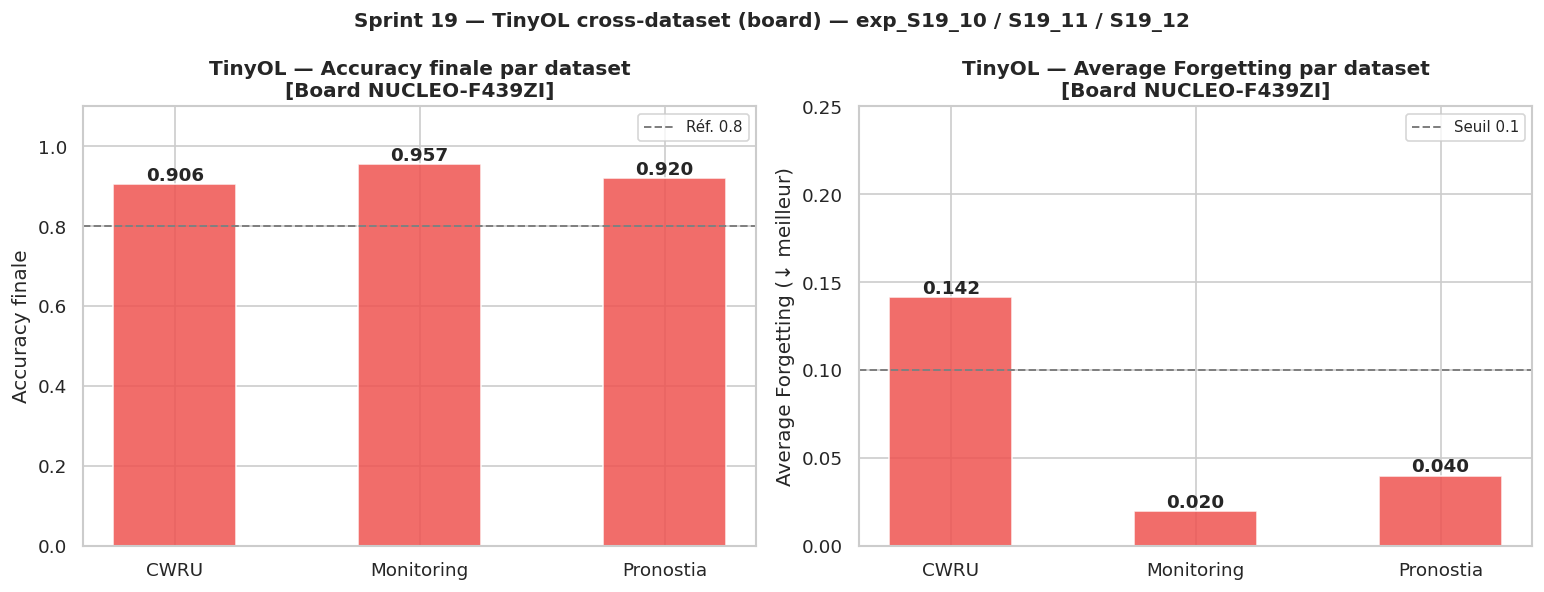

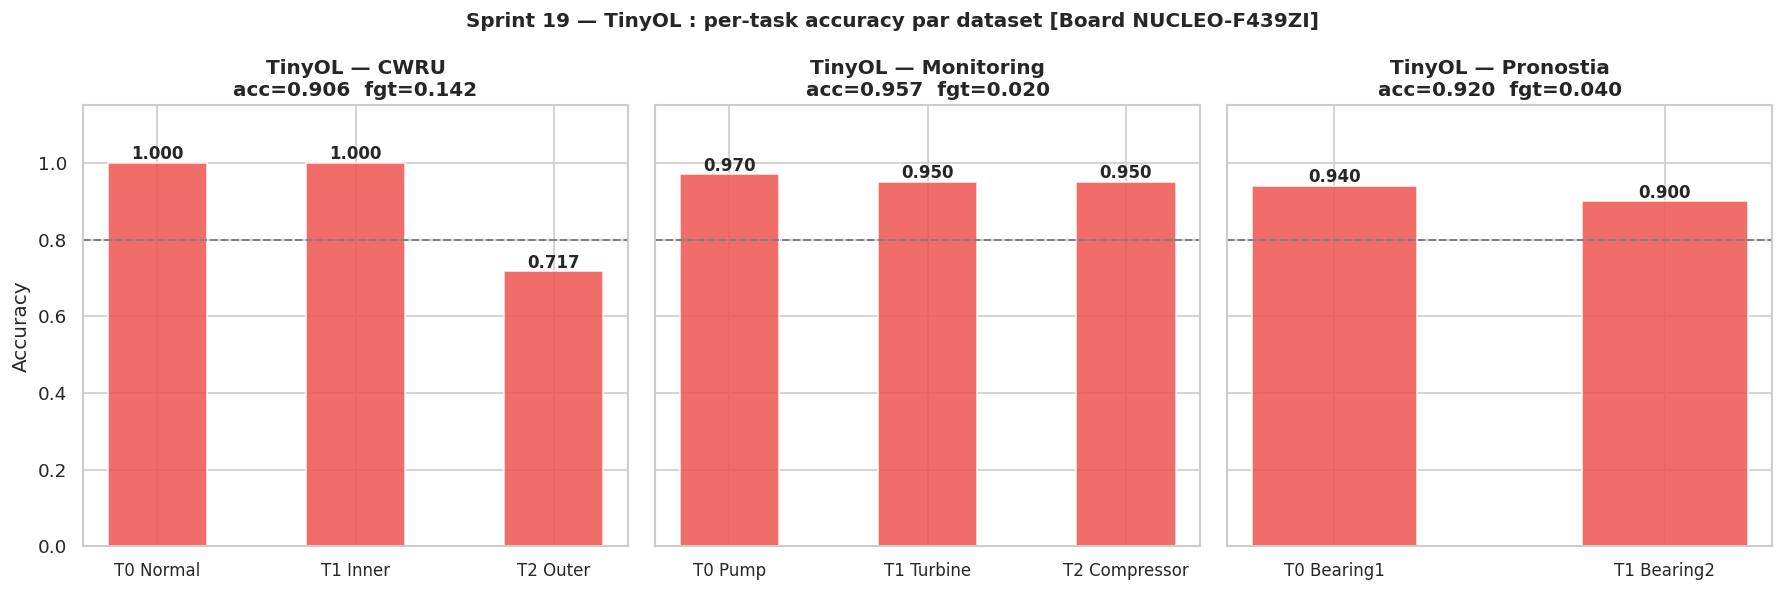

TinyOL CWRU      : acc=0.906  fgt=0.142  lat=0.126ms  RAM=5800B
TinyOL Monitoring: acc=0.957  fgt=0.020  lat=0.126ms  RAM=5800B
TinyOL Pronostia : acc=0.920  fgt=0.040  lat=0.126ms  RAM=5800B


In [23]:
s19_10 = json.load(open("../experiments/exp_S19_10/results.json"))  # TinyOL CWRU board
s19_11 = json.load(open("../experiments/exp_S19_11/results.json"))  # TinyOL Monitoring board
s19_12 = json.load(open("../experiments/exp_S19_12/results.json"))  # TinyOL Pronostia board

TINYOL_COL = "#EF5350"
tinyol_datasets = ["CWRU", "Monitoring", "Pronostia"]
tinyol_results  = [s19_10, s19_11, s19_12]
task_names_tinyol = {
    "CWRU":       ["T0 Normal", "T1 Inner", "T2 Outer"],
    "Monitoring": ["T0 Pump",   "T1 Turbine", "T2 Compressor"],
    "Pronostia":  ["T0 Bearing1", "T1 Bearing2"],
}

# ── Figure 1 : acc_final + avg_forgetting par dataset ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(3)

acc_vals = [r["acc_final"]      for r in tinyol_results]
fgt_vals = [r["avg_forgetting"] for r in tinyol_results]

ax = axes[0]
bars = ax.bar(x, acc_vals, color=TINYOL_COL, alpha=0.85, width=0.5, edgecolor="white")
for bar, v in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008,
            f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(tinyol_datasets, fontsize=11)
ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2, label="Réf. 0.8")
ax.set_ylim(0, 1.1); ax.set_ylabel("Accuracy finale")
ax.set_title("TinyOL — Accuracy finale par dataset\n[Board NUCLEO-F439ZI]", fontweight="bold")
ax.legend(fontsize=9)

ax = axes[1]
bars = ax.bar(x, fgt_vals, color=TINYOL_COL, alpha=0.85, width=0.5, edgecolor="white")
for bar, v in zip(bars, fgt_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.002,
            f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(tinyol_datasets, fontsize=11)
ax.axhline(0.1, color="gray", linestyle="--", linewidth=1.2, label="Seuil 0.1")
ax.set_ylim(0, 0.25); ax.set_ylabel("Average Forgetting (↓ meilleur)")
ax.set_title("TinyOL — Average Forgetting par dataset\n[Board NUCLEO-F439ZI]", fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("Sprint 19 — TinyOL cross-dataset (board) — exp_S19_10 / S19_11 / S19_12",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "16a_tinyol_cross_dataset.png", bbox_inches="tight")
plt.show()

# ── Figure 2 : Per-task accuracy — 3 subplots ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, (r, dataset) in zip(axes, zip(tinyol_results, tinyol_datasets)):
    n_tasks   = r["n_tasks"]
    task_lbls = task_names_tinyol[dataset][:n_tasks]
    task_vals = [r["per_task_acc"][str(t)] for t in range(n_tasks)]
    xp = np.arange(n_tasks)
    bars = ax.bar(xp, task_vals, color=TINYOL_COL, alpha=0.85, width=0.5, edgecolor="white")
    for bar, v in zip(bars, task_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.axhline(0.8, color="gray", linestyle="--", linewidth=1.2)
    ax.set_xticks(xp); ax.set_xticklabels(task_lbls, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Accuracy" if dataset == "CWRU" else "")
    ax.set_title(f"TinyOL — {dataset}\nacc={r['acc_final']:.3f}  fgt={r['avg_forgetting']:.3f}",
                 fontweight="bold")

fig.suptitle("Sprint 19 — TinyOL : per-task accuracy par dataset [Board NUCLEO-F439ZI]",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "16b_tinyol_pertask.png", bbox_inches="tight")
plt.show()

for r, d in zip(tinyol_results, tinyol_datasets):
    print(f"TinyOL {d:10s}: acc={r['acc_final']:.3f}  fgt={r['avg_forgetting']:.3f}  lat={r['inference_latency_ms']:.3f}ms  RAM={r['ram_peak_bytes']}B")

---
## 17. Comparaison complète — 4 modèles × 3 datasets (board)

Vue consolidée de toutes les expériences board Sprint 19 : Mahalanobis, EWC, HDC, TinyOL × CWRU/Monitoring/Pronostia.
Inclut : heatmaps acc/fgt, scatter latence vs accuracy, tableau récapitulatif complet (18 expériences).

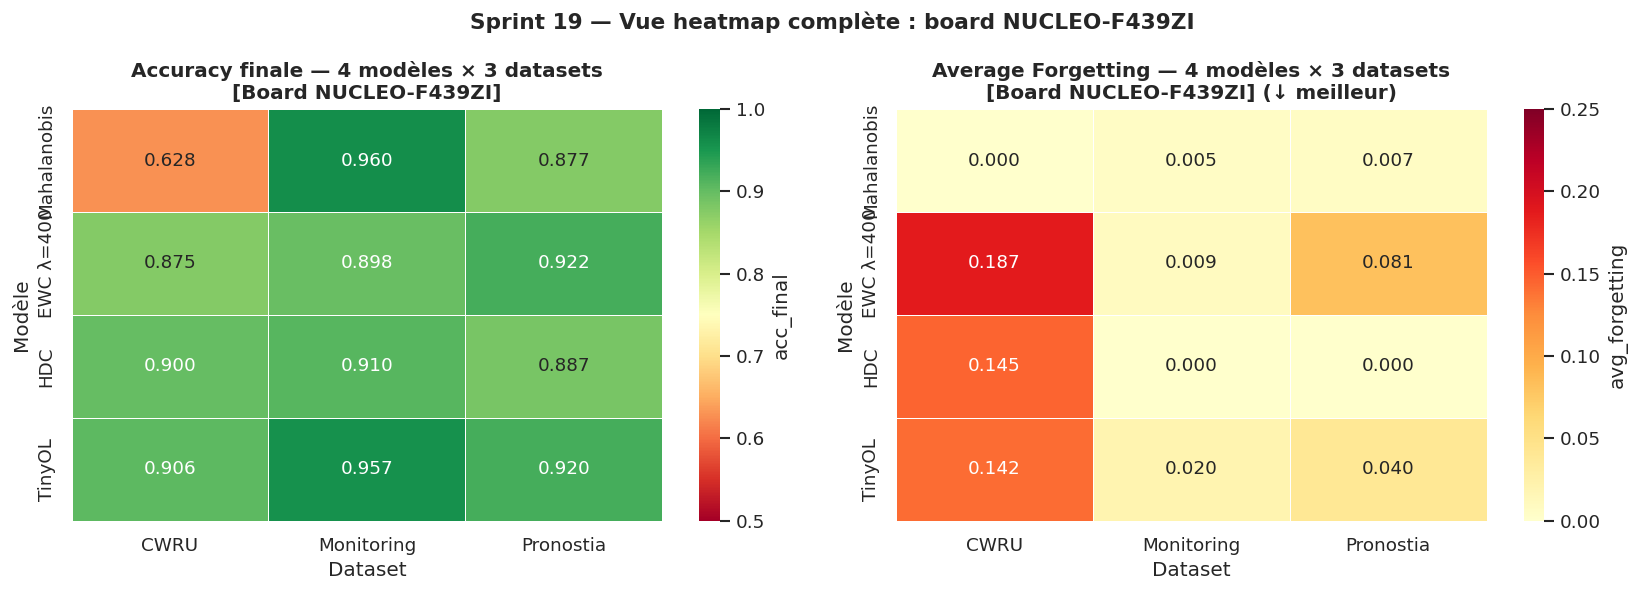

In [24]:
import pandas as pd

# ── Données board consolidées : modèle × dataset ──
# Ligne = modèle, Colonne = dataset
MODELS_ORDER   = ["Mahalanobis", "EWC λ=400", "HDC", "TinyOL"]
DATASETS_ORDER = ["CWRU", "Monitoring", "Pronostia"]

# acc_final[modèle][dataset]
acc_board = {
    "Mahalanobis": {"CWRU": s19_01["acc_final"],          "Monitoring": mahal_board["Monitoring"]["acc_final"], "Pronostia": mahal_board["Pronostia"]["acc_final"]},
    "EWC λ=400":   {"CWRU": s19_05["acc_final"],           "Monitoring": s19_02_e400_brd["acc_final"],           "Pronostia": s19_06["acc_final"]},
    "HDC":         {"CWRU": s19_07["acc_final"],           "Monitoring": s19_08["acc_final"],                    "Pronostia": s19_09["acc_final"]},
    "TinyOL":      {"CWRU": s19_10["acc_final"],           "Monitoring": s19_11["acc_final"],                    "Pronostia": s19_12["acc_final"]},
}
fgt_board = {
    "Mahalanobis": {"CWRU": s19_01["avg_forgetting"],      "Monitoring": mahal_board["Monitoring"]["avg_forgetting"], "Pronostia": mahal_board["Pronostia"]["avg_forgetting"]},
    "EWC λ=400":   {"CWRU": s19_05["avg_forgetting"],      "Monitoring": s19_02_e400_brd["avg_forgetting"],           "Pronostia": s19_06["avg_forgetting"]},
    "HDC":         {"CWRU": s19_07["avg_forgetting"],      "Monitoring": s19_08["avg_forgetting"],                    "Pronostia": s19_09["avg_forgetting"]},
    "TinyOL":      {"CWRU": s19_10["avg_forgetting"],      "Monitoring": s19_11["avg_forgetting"],                    "Pronostia": s19_12["avg_forgetting"]},
}

acc_mat = np.array([[acc_board[m][d] for d in DATASETS_ORDER] for m in MODELS_ORDER])
fgt_mat = np.array([[fgt_board[m][d] for d in DATASETS_ORDER] for m in MODELS_ORDER])

# ── Heatmaps acc_final + avg_forgetting ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.heatmap(acc_mat, ax=ax, vmin=0.5, vmax=1.0, annot=True, fmt=".3f",
            cmap="RdYlGn", linewidths=0.5, cbar_kws={"label": "acc_final"},
            xticklabels=DATASETS_ORDER, yticklabels=MODELS_ORDER)
ax.set_title("Accuracy finale — 4 modèles × 3 datasets\n[Board NUCLEO-F439ZI]", fontweight="bold")
ax.set_xlabel("Dataset"); ax.set_ylabel("Modèle")

ax = axes[1]
sns.heatmap(fgt_mat, ax=ax, vmin=0.0, vmax=0.25, annot=True, fmt=".3f",
            cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "avg_forgetting"},
            xticklabels=DATASETS_ORDER, yticklabels=MODELS_ORDER)
ax.set_title("Average Forgetting — 4 modèles × 3 datasets\n[Board NUCLEO-F439ZI] (↓ meilleur)",
             fontweight="bold")
ax.set_xlabel("Dataset"); ax.set_ylabel("Modèle")

fig.suptitle("Sprint 19 — Vue heatmap complète : board NUCLEO-F439ZI",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "17a_heatmap_4models_3datasets.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_83905/4135557337.py:43: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_83905/4135557337.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "17b_latency_vs_accuracy_all.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


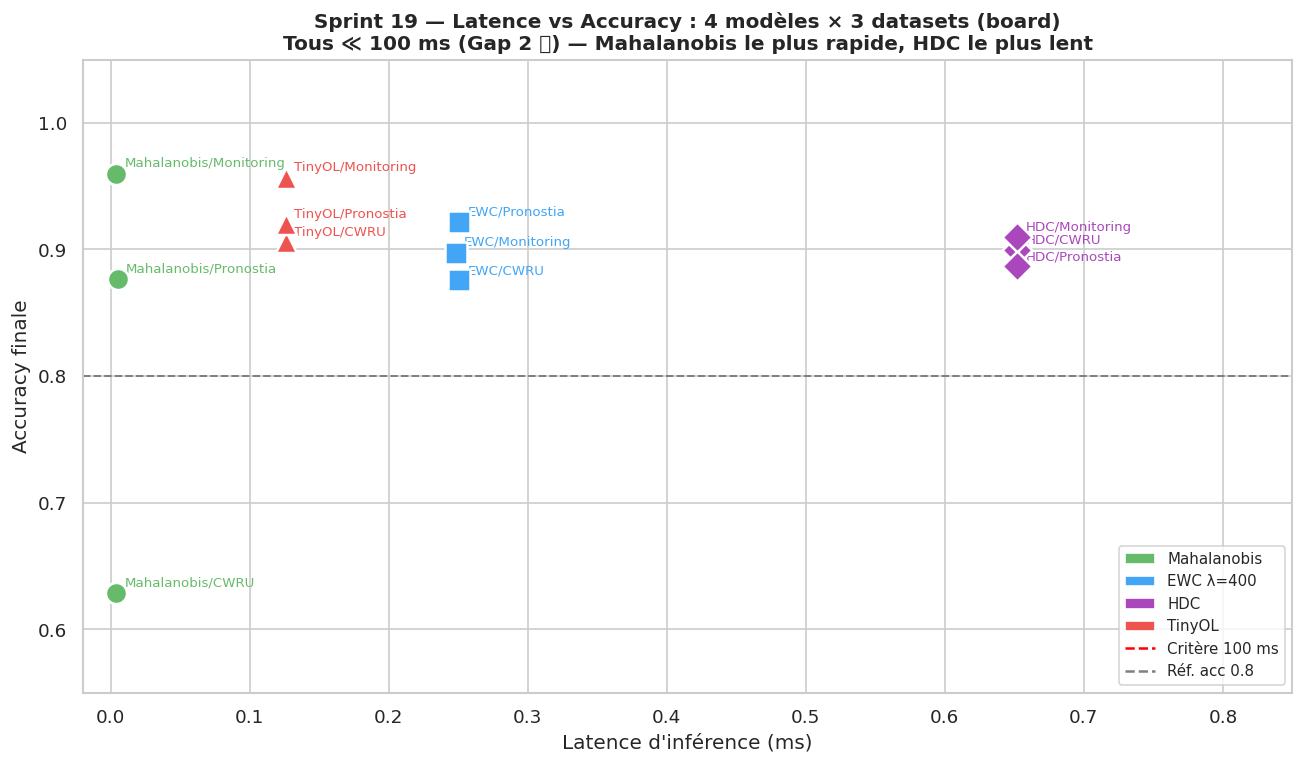

In [25]:
# ── Scatter étendu : latence vs accuracy — tous les modèles board ──
lat_data = {
    "Mahalanobis/CWRU":      (s19_01["inference_latency_ms"],          s19_01["acc_final"],          "#66BB6A", "o"),
    "Mahalanobis/Monitoring":(mahal_board["Monitoring"]["inference_latency_ms"], mahal_board["Monitoring"]["acc_final"], "#66BB6A", "o"),
    "Mahalanobis/Pronostia": (mahal_board["Pronostia"]["inference_latency_ms"],  mahal_board["Pronostia"]["acc_final"],  "#66BB6A", "o"),
    "EWC/CWRU":              (s19_05["inference_latency_ms"],           s19_05["acc_final"],           "#42A5F5", "s"),
    "EWC/Monitoring":        (s19_02_e400_brd["inference_latency_ms"],  s19_02_e400_brd["acc_final"],  "#42A5F5", "s"),
    "EWC/Pronostia":         (s19_06["inference_latency_ms"],           s19_06["acc_final"],           "#42A5F5", "s"),
    "HDC/CWRU":              (s19_07["inference_latency_ms"],           s19_07["acc_final"],           "#AB47BC", "D"),
    "HDC/Monitoring":        (s19_08["inference_latency_ms"],           s19_08["acc_final"],           "#AB47BC", "D"),
    "HDC/Pronostia":         (s19_09["inference_latency_ms"],           s19_09["acc_final"],           "#AB47BC", "D"),
    "TinyOL/CWRU":           (s19_10["inference_latency_ms"],           s19_10["acc_final"],           "#EF5350", "^"),
    "TinyOL/Monitoring":     (s19_11["inference_latency_ms"],           s19_11["acc_final"],           "#EF5350", "^"),
    "TinyOL/Pronostia":      (s19_12["inference_latency_ms"],           s19_12["acc_final"],           "#EF5350", "^"),
}

fig, ax = plt.subplots(figsize=(11, 6.5))
for label, (lat, acc, color, marker) in lat_data.items():
    ax.scatter(lat, acc, color=color, marker=marker, s=160,
               zorder=5, edgecolors="white", linewidths=1.5)
    ax.annotate(label, (lat, acc), xytext=(5, 4), textcoords="offset points",
                fontsize=8, color=color)

ax.axvline(100, color="red", linestyle="--", linewidth=1.5, label="Critère 100 ms (Gap 2)")
ax.axhline(0.8,  color="gray", linestyle="--", linewidth=1.2, label="Réf. acc 0.8")

legend_elements = [
    mpatches.Patch(facecolor="#66BB6A", label="Mahalanobis"),
    mpatches.Patch(facecolor="#42A5F5", label="EWC λ=400"),
    mpatches.Patch(facecolor="#AB47BC", label="HDC"),
    mpatches.Patch(facecolor="#EF5350", label="TinyOL"),
    plt.Line2D([0], [0], color="red",  linestyle="--", label="Critère 100 ms"),
    plt.Line2D([0], [0], color="gray", linestyle="--", label="Réf. acc 0.8"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower right")
ax.set_xlabel("Latence d'inférence (ms)")
ax.set_ylabel("Accuracy finale")
ax.set_title("Sprint 19 — Latence vs Accuracy : 4 modèles × 3 datasets (board)\n"
             "Tous ≪ 100 ms (Gap 2 ✅) — Mahalanobis le plus rapide, HDC le plus lent",
             fontweight="bold")
ax.set_xlim(-0.02, 0.85)
ax.set_ylim(0.55, 1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / "17b_latency_vs_accuracy_all.png", bbox_inches="tight")
plt.show()

In [26]:
import pandas as pd

# ── Tableau récapitulatif complet — toutes les expériences board S19 ──
all_board_rows = [
    # (exp_id, modèle, dataset, résultat)
    ("exp_S19_01", "Mahalanobis", "CWRU",       s19_01),
    ("exp_S19_03", "Mahalanobis", "Pronostia",  mahal_board["Pronostia"]),
    ("exp_S19_04", "Mahalanobis", "Monitoring", mahal_board["Monitoring"]),
    ("exp_S19_02", "EWC λ=400",   "Monitoring", s19_02_e400_brd),
    ("exp_S19_05", "EWC λ=400",   "CWRU",       s19_05),
    ("exp_S19_06", "EWC λ=400",   "Pronostia",  s19_06),
    ("exp_S19_07", "HDC",         "CWRU",       s19_07),
    ("exp_S19_08", "HDC",         "Monitoring", s19_08),
    ("exp_S19_09", "HDC",         "Pronostia",  s19_09),
    ("exp_S19_10", "TinyOL",      "CWRU",       s19_10),
    ("exp_S19_11", "TinyOL",      "Monitoring", s19_11),
    ("exp_S19_12", "TinyOL",      "Pronostia",  s19_12),
]

rows = []
for exp_id, model, dataset, r in all_board_rows:
    rows.append({
        "Exp":           exp_id,
        "Modèle":        model,
        "Dataset":       dataset,
        "acc_final":     f"{r['acc_final']:.3f}",
        "avg_fgt":       f"{r['avg_forgetting']:.3f}",
        "lat (ms)":      f"{r['inference_latency_ms']:.3f}",
        "RAM (B)":       r.get("ram_peak_bytes", "—"),
        "n_params":      r.get("n_params", "—"),
        "Gap2 RAM":      "✅" if r.get("gap2_ram_compliant", True) else "❌",
        "Gap2 Lat":      "✅" if r.get("gap2_latency_compliant", True) else "❌",
    })

df = pd.DataFrame(rows)
print(f"Total : {len(df)} expériences board Sprint 19\n")
display(df.to_html(index=False))

# Export CSV pour référence
df.to_csv(FIG_DIR / "17c_board_summary_s19.csv", index=False)
print(f"\nTableau exporté : {FIG_DIR / '17c_board_summary_s19.csv'}")

Total : 12 expériences board Sprint 19



'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Exp</th>\n      <th>Modèle</th>\n      <th>Dataset</th>\n      <th>acc_final</th>\n      <th>avg_fgt</th>\n      <th>lat (ms)</th>\n      <th>RAM (B)</th>\n      <th>n_params</th>\n      <th>Gap2 RAM</th>\n      <th>Gap2 Lat</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>exp_S19_01</td>\n      <td>Mahalanobis</td>\n      <td>CWRU</td>\n      <td>0.628</td>\n      <td>0.000</td>\n      <td>0.004</td>\n      <td>0</td>\n      <td>30</td>\n      <td>✅</td>\n      <td>✅</td>\n    </tr>\n    <tr>\n      <td>exp_S19_03</td>\n      <td>Mahalanobis</td>\n      <td>Pronostia</td>\n      <td>0.877</td>\n      <td>0.007</td>\n      <td>0.005</td>\n      <td>0</td>\n      <td>30</td>\n      <td>✅</td>\n      <td>✅</td>\n    </tr>\n    <tr>\n      <td>exp_S19_04</td>\n      <td>Mahalanobis</td>\n      <td>Monitoring</td>\n      <td>0.960</td>\n      <td>0.005</td>\n      <td>0.004</td>\n   


Tableau exporté : ../experiments/figures/sprint19/17c_board_summary_s19.csv


---
## 18. RAM par modèle — Empreinte mémoire board (NUCLEO-F439ZI)

**Source** : fichier `.map` linker `firmware/stm32f4_blink/build/stm32f4_blink.map` — taille exacte de chaque struct en `.bss` mesurée au link time.  
Budget total NUCLEO-F439ZI : **256 Ko**. Limite Gap 2 : **64 Ko**.

| Symbole `.bss` | Modèle | RAM réelle |
|---------------|--------|------------|
| `g_detector` | Mahalanobis | 128 B |
| `g_ewc_head` | EWC λ=400 | 8 652 B |
| `g_tinyol_enc + g_tinyol_dec` | TinyOL | 5 716 B |
| `g_hdc` | HDC | 28 312 B |

/tmp/ipykernel_83905/2525577986.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_83905/2525577986.py:55: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "18a_ram_par_modele.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


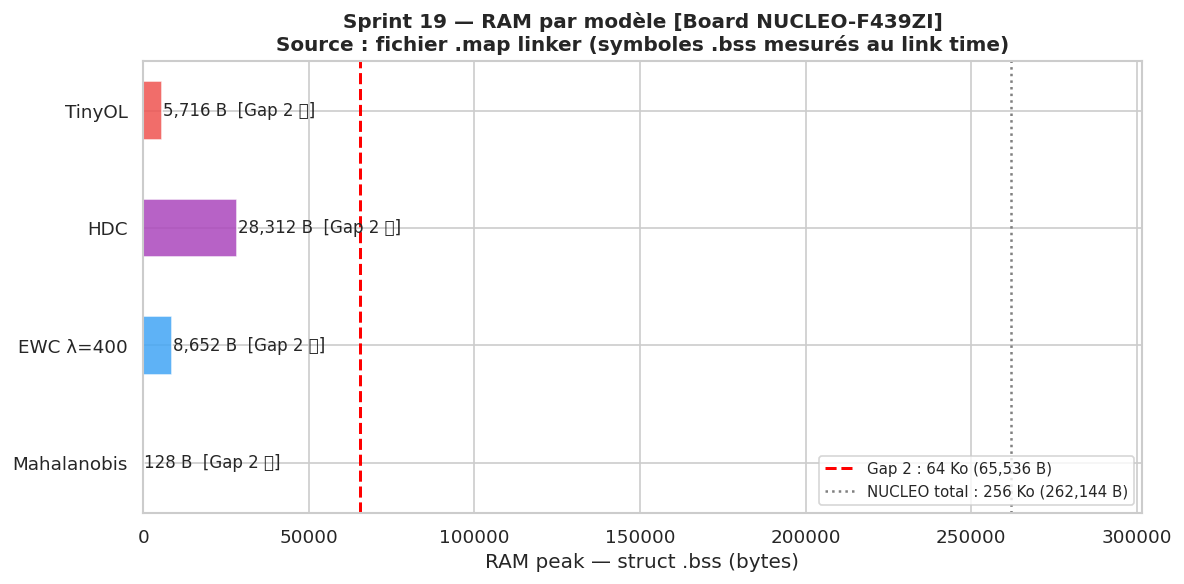

RAM lue depuis : ../firmware/stm32f4_blink/build/stm32f4_blink.map
RAM board Sprint 19 (symboles .bss linker) :
  Mahalanobis    :    128 B  (0.1 Ko)  Gap 2 ✅
  EWC λ=400      :  8,652 B  (8.4 Ko)  Gap 2 ✅
  HDC            : 28,312 B  (27.6 Ko)  Gap 2 ✅
  TinyOL         :  5,716 B  (5.6 Ko)  Gap 2 ✅


In [27]:
# ── Section 18 : RAM par modèle — valeurs lues depuis le .map linker ──
import re, sys
sys.path.insert(0, str(Path("..").resolve()))

def read_bss_from_map(map_path):
    """Retourne {symbol_name: bytes} pour chaque .bss.gXxx non-nul."""
    text = Path(map_path).read_text()
    matches = re.findall(r'\.bss\.(\w+)\s+0x[0-9a-f]+\s+0x([0-9a-f]+)', text)
    return {name: int(sz, 16) for name, sz in matches if int(sz, 16) > 0}

MAP_PATH = "../firmware/stm32f4_blink/build/stm32f4_blink.map"
bss = read_bss_from_map(MAP_PATH)

# RAM par modèle = symboles .bss du struct principal (linker map)
ram_vals = {
    "Mahalanobis": bss.get("g_detector", 128),                        # MahalanobisDetector struct
    "EWC λ=400":   bss.get("g_ewc_head", 8652),                       # EWCHeadReg struct
    "HDC":         bss.get("g_hdc", 28312),                           # HdcClassifier struct
    "TinyOL":      bss.get("g_tinyol_enc", 2880) + bss.get("g_tinyol_dec", 2836),  # encoder + decoder
}
ram_sources = {m: "map linker" for m in ram_vals}
ram_colors = {
    "Mahalanobis": "#66BB6A",
    "EWC λ=400":   "#42A5F5",
    "HDC":         "#AB47BC",
    "TinyOL":      "#EF5350",
}
GAP2_LIMIT   = 65_536    # 64 Ko — critère Gap 2
NUCLEO_TOTAL = 262_144   # 256 Ko — RAM totale NUCLEO-F439ZI

models_ram = list(ram_vals.keys())
values_ram = [ram_vals[m] for m in models_ram]
colors_ram = [ram_colors[m] for m in models_ram]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(models_ram, values_ram, color=colors_ram, alpha=0.85, edgecolor="white", height=0.5)

ax.axvline(GAP2_LIMIT,   color="red",  linestyle="--", linewidth=1.8,
           label=f"Gap 2 : 64 Ko ({GAP2_LIMIT:,} B)")
ax.axvline(NUCLEO_TOTAL, color="gray", linestyle=":",  linewidth=1.5,
           label=f"NUCLEO total : 256 Ko ({NUCLEO_TOTAL:,} B)")

for bar, model, val in zip(bars, models_ram, values_ram):
    gap2 = "Gap 2 ✅" if val < GAP2_LIMIT else "Gap 2 ❌"
    ax.text(val + 200, bar.get_y() + bar.get_height() / 2,
            f"{val:,} B  [{gap2}]", va="center", fontsize=10)

ax.set_xlabel("RAM peak — struct .bss (bytes)")
ax.set_title("Sprint 19 — RAM par modèle [Board NUCLEO-F439ZI]\n"
             "Source : fichier .map linker (symboles .bss mesurés au link time)",
             fontweight="bold")
ax.set_xlim(0, NUCLEO_TOTAL * 1.15)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "18a_ram_par_modele.png", bbox_inches="tight")
plt.show()

print(f"RAM lue depuis : {MAP_PATH}")
print("RAM board Sprint 19 (symboles .bss linker) :")
for m, v in ram_vals.items():
    gap2 = "✅" if v < GAP2_LIMIT else "❌"
    print(f"  {m:15s}: {v:6,} B  ({v/1024:.1f} Ko)  Gap 2 {gap2}")


---
## 19. Coût de calcul — MACs par inférence (analytique)

Estimations analytiques via `src/evaluation/compute_cost.py` avec les hyperparamètres des configs board YAML.  
Seules les opérations multiply-accumulate dominantes sont comptées (activations < 5 % du total).  

| Modèle | Architecture | MACs / inférence |
|--------|-------------|------------------|
| Mahalanobis | n_features=5 | 30 |
| EWC | MLP 5→32→16→2 | 704 |
| TinyOL | Enc 5→32→16→5 | 752 |
| HDC | D=1000, F=5, C=2 | 7 000 |

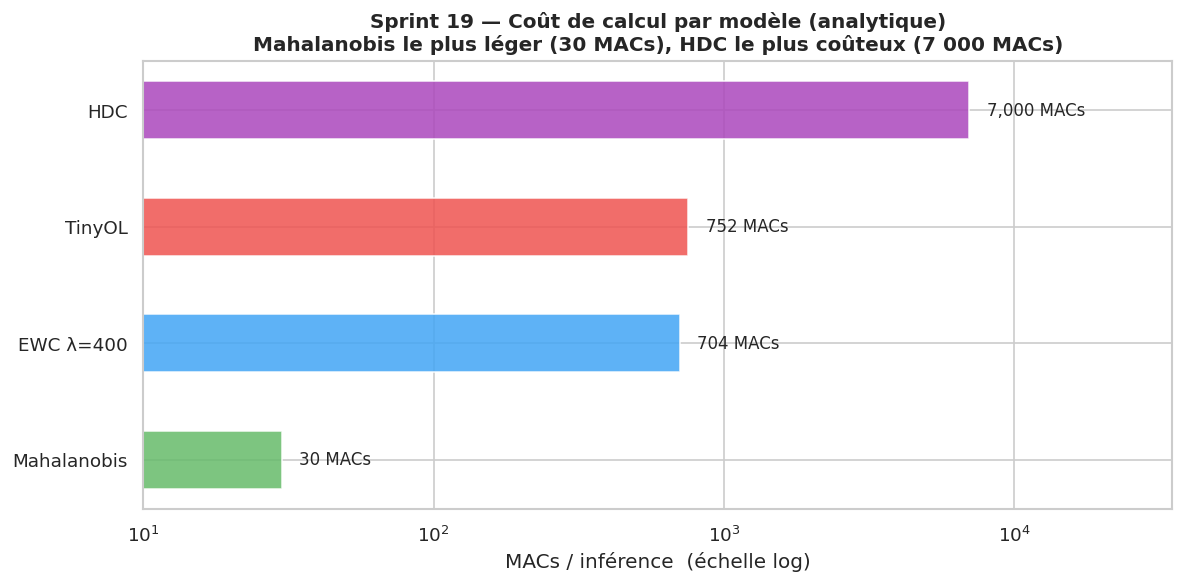

MACs / inférence (board configs) :
  Mahalanobis    :     30 MACs
  EWC λ=400      :    704 MACs
  TinyOL         :    752 MACs
  HDC            :  7,000 MACs


In [28]:
# ── Section 19 : MACs par inférence ──
import sys
sys.path.insert(0, str(Path("..").resolve()))
from src.evaluation.compute_cost import (
    macs_ewc_mlp, macs_tinyol, macs_hdc, macs_mahalanobis
)

# Hyperparamètres board YAML (configs/board_*.yaml)
macs_vals = {
    "Mahalanobis": macs_mahalanobis(n_features=5),          # board_mahalanobis.yaml : MAHA_DIM=5
    "EWC λ=400":   macs_ewc_mlp(5, [32, 16], 2),           # board_ewc.yaml : IN=5 H1=32 H2=16 OUT=2
    "TinyOL":      macs_tinyol(5, [32, 16], 5),            # board_tinyol.yaml : IN=5 H1=32 EMB=16 OUT=5
    "HDC":         macs_hdc(5, 1000, 2),                   # board_hdc.yaml : F=5 D=1000 C=2
}

models_macs  = list(macs_vals.keys())
values_macs  = [macs_vals[m] for m in models_macs]
colors_macs  = [ram_colors[m] for m in models_macs]  # réutilise les couleurs par modèle

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(models_macs, values_macs, color=colors_macs, alpha=0.85, edgecolor="white", height=0.5,
               log=True)

# Annotations valeur exacte
for bar, model, val in zip(bars, models_macs, values_macs):
    ax.text(val * 1.15, bar.get_y() + bar.get_height() / 2,
            f"{val:,} MACs", va="center", fontsize=10)

ax.set_xlabel("MACs / inférence  (échelle log)")
ax.set_title("Sprint 19 — Coût de calcul par modèle (analytique)\n"
             "Mahalanobis le plus léger (30 MACs), HDC le plus coûteux (7 000 MACs)",
             fontweight="bold")
ax.set_xlim(10, max(values_macs) * 5)
plt.tight_layout()
plt.savefig(FIG_DIR / "19a_macs_par_modele.png", bbox_inches="tight")
plt.show()

print("MACs / inférence (board configs) :")
for m, v in macs_vals.items():
    print(f"  {m:15s}: {v:6,} MACs")